In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import pandas as pd
from pathlib import Path
from hypo_sleep import Session
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
from functools import partial
from ghostipy.dsp import signal_envelope

In [2]:
def xr_baseline_correction(data, baseline_segment):
    if not isinstance(baseline_segment, slice):
        baseline_segment = slice(baseline_segment[0], baseline_segment[1])
    baseline_data = data.sel(time=baseline_segment).copy()
    corrected_data = (
        (data - baseline_data.mean(dim="time")) / baseline_data.mean(dim="time")
    ) * 100
    return corrected_data

In [3]:
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 22
BIGGEST_SIZE = 26

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes titlea
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [4]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "HYDO03": {
        "dates": [
            "2025-02-18_09-19-26",
            "2025-02-19_08-59-23",
            "2025-02-20_08-58-57",
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-03_08-55-10",
        ],
        "configs": [
            "0875",
            "d628",
            "119b",
            "a964",
            "0674",
            "c687",
        ],  # ["85bd", "edfe"],  # ["f1b1", "5fdd"],
        "condition": ["none", "sleep", "none", "food", "food", "sleep"],
    },
    "HYDO04": {
        "dates": [
            "2025-02-24_09-00-29",
            "2025-02-25_09-06-23",
            "2025-02-26_09-05-08",
            "2025-03-04_08-55-25",
            "2025-03-07_08-52-44",
        ],
        "configs": ["f1ef", "073a", "f95a", "bc96", "9080"],  # ["8e29", "d678"],
        "condition": ["none", "sleep", "none", "food", "sleep"],
    },
}
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)

In [5]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
# data_path = Path("/mnt/data/raw/", animal, date)
data_path = Path("/gpfs01/born/animal/Hypothalamic_Sleep/data/raw")

In [6]:
session_dict = {}
for animal in full_dict.keys():
    animal_dict = full_dict[animal]
    for date, config_id in zip(animal_dict["dates"], animal_dict["configs"]):
        session_dict[date] = Session(
            config_path, animal, date, config_id, **{"base_path": "remote"}
        )

In [7]:
def artifact_detection(recording, **params):
    artf_thresh = params.get("artifact_detect_std_thresh", np.inf)

    if params.get("artifact_detect_method") == "zscore":
        art_rec = spp.zscore(recording)
    artifacts = np.zeros(
        (recording.get_num_channels(), recording.get_num_samples()), dtype=bool
    )
    artifact_ch_list = []
    for i, ch in enumerate(art_rec.get_channel_ids()):
        artifact_ch_list.append(ch)
        artifacts[
            i,
            np.where(
                np.abs(
                    art_rec.get_traces(channel_ids=[ch], return_scaled=True).flatten()
                )
                > artf_thresh
            )[0],
        ] = True
    ch_artifact_sum = np.sum(artifacts, axis=0)
    ch_count_remove = max(
        int(recording.get_num_channels() * params.get("artifact_detect_ch_frac", 1)), 1
    )
    above_thresh = np.ravel(np.argwhere(ch_artifact_sum >= ch_count_remove))
    return above_thresh

In [8]:
# window = 10.001
rec_dict = {
    date: {
        region: {filt_type: [] for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
art_dict = {
    date: {
        region: {filt_type: None for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
params = {
    "artifact_detect_ch_frac": 0.5,
    "artifact_detect_method": "zscore",
    "artifact_detect_std_thresh": 5.0,
    "artifact_removal_ms": 0.5,
}
for animal, animal_dict in full_dict.items():
    for date in animal_dict["dates"]:
        for region in rec_dict[date].keys():
            for filt_type in ["raw", "so"]:
                if filt_type == "raw":
                    ref_id = (
                        "250_132b_ctx_global_fe80"
                        if region == "hyp"
                        else "250_132b_none_1da2"
                    )
                elif filt_type == "so":
                    ref_id = (
                        "ctx_global_fe80_so_3c1a"
                        if region == "hyp"
                        else "none_1da2_so_3c1a"
                    )
                rec_dir = list(
                    Path(config_path, animal, date, "rec", region).glob(ref_id)
                )[0]
                recording = si.load(rec_dir)
                artifact_triggers = artifact_detection(recording, **params)
                artifact_mask = np.zeros(
                    shape=(recording.get_num_samples()), dtype=bool
                )
                artifact_mask[artifact_triggers] = True
                art_dict[date][region][filt_type] = artifact_mask
                clean_rec = spp.remove_artifacts(
                    recording=recording,
                    list_triggers=artifact_triggers,
                    mode="zeros",
                    fit_sample_spacing=4.0,
                    ms_before=params["artifact_removal_ms"],
                    ms_after=params["artifact_removal_ms"],
                )
                rec_dict[date][region][filt_type] = clean_rec

In [9]:
from itertools import groupby
from operator import itemgetter


def get_span_start_stop(indices):
    """Get start and stop indices of spans of consecutive indices"""
    span_inds = []
    for k, g in groupby(enumerate(indices), lambda x: x[1] - x[0]):
        group = list(map(itemgetter(1), g))
        span_inds.append((group[0], group[-1]))
    return span_inds

In [10]:
xcorr_win = 3  # minutes
xcorr_ind_win = xcorr_win * 60
trace_dict = {
    date: {
        region: {sig_type: {"trace": [], "time": []} for sig_type in recs.keys()}
        for region, recs in rec_dict[date].items()
    }
    for date, session in session_dict.items()
}
buf = 0.001
for date, session in session_dict.items():
    # for state, state_info in session.state_dict.items():
    for region, recs in rec_dict[date].items():
        for sig_type, rec in recs.items():
            times = rec.get_times()
            spans = get_span_start_stop(np.where(~art_dict[date][region][sig_type])[0])
            good_chunks = np.array(
                [
                    [times[start], times[stop]]
                    for start, stop in spans
                    if times[stop] - times[start] > xcorr_ind_win
                ]
            )
            channels = (
                ["39"] if region == "ctx" else rec.get_channel_ids()
            )  # sub_channels
            rec_end_time = rec.get_end_time()
            # start_time = rec.get_start_time()
            tmp_traces = []
            tmp_times = []
            for start, stop in good_chunks:
                while (start + xcorr_ind_win < stop) & (
                    start + xcorr_ind_win + buf < rec_end_time
                ):
                    # while start_time + xcorr_ind_win < rec_end_time:
                    tmp_rec = rec.time_slice(
                        start_time=start, end_time=start + xcorr_ind_win + buf
                    )
                    tmp_times.append(
                        tmp_rec.get_times()[
                            : int(xcorr_ind_win * rec.get_sampling_frequency())
                        ]
                    )
                    tmp_trace = tmp_rec.get_traces(
                        channel_ids=channels, return_scaled=True
                    )
                    # tmp_trace[np.where(tmp_trace == 0)] = np.nan
                    tmp_traces.append(
                        tmp_trace[: int(xcorr_ind_win * rec.get_sampling_frequency())]
                    )
                    start += xcorr_ind_win
            trace_dict[date][region][sig_type]["time"] = np.array(tmp_times)
            trace_dict[date][region][sig_type]["trace"] = np.array(tmp_traces)

In [ ]:
# trace_dict = {
#     date: {
#         state: {
#             region: {sig_type: {"trace": [], "time": []} for sig_type in recs.keys()}
#             for region, recs in rec_dict[date].items()
#         }
#         for state in session.state_dict.keys()
#     }
#     for date, session in session_dict.items()
# }
# for date, session in session_dict.items():
#     # for state, state_info in session.state_dict.items():
#         for region, recs in rec_dict[date].items():
#             for sig_type, rec in recs.items():
#                 channels = (
#                     ["39"] if region == "ctx" else rec.get_channel_ids()
#                 )  # sub_channels
#                 rec_end_time = rec.get_end_time()
#                 while start_time + xcorr_win < rec_end_time:
#                     tmp_rec = rec.time_slice(start_time=start_time, end_time=start_time+xcorr_win)
#                     trace_dict[date][state][region][sig_type]["time"].append(
#                         tmp_rec.get_times()
#                     )
#                     tmp_trace = tmp_rec.get_traces(
#                         channel_ids=channels, return_scaled=True
#                     )
#                     tmp_trace[np.where(tmp_trace == 0)] = np.nan
#                     trace_dict[date][state][region][sig_type]["trace"].append(tmp_trace)
#                     start_time += xcorr_win

### X-Corr Func

In [ ]:
region = "hyp"
ref_ch_inds = np.array([1, 15, -2])
ref_chs = depth_ordered_chs[::-1][ref_ch_inds]
ref_rec_ch_inds = [np.argwhere(rec.get_channel_ids() == ch)[0][0] for ch in ref_chs]
np.argsort(
    rec.get_channel_ids(),
)
date_xcf = {}
sorted_rec_chs = np.array(
    [np.argwhere(rec.get_channel_ids() == ch)[0][0] for ch in depth_ordered_chs[::-1]]
)
for date, date_dict in trace_dict.items():
    date_xcf[date] = {}
    trace_date_dict = date_dict[region]["raw"]["trace"]
    xcf = np.zeros(shape=(3, 32, trace_date_dict.shape[0], 1000))
    for k_epoch in range(trace_date_dict.shape[0]):
        tmp_trace_dict = trace_date_dict[k_epoch, :, :]
        for i, ref_ind in enumerate(ref_rec_ch_inds):
            tmp_ref_trace = tmp_trace_dict[:, ref_ind]
            for j, ch_ind in enumerate(sorted_rec_chs):
                tmp_targ_trace = tmp_trace_dict[:, ch_ind]
                bkwds = sm.tsa.ccf(
                    tmp_targ_trace, tmp_ref_trace, fft=True, adjusted=False, nlags=751
                )[::-1]
                fwds = sm.tsa.ccf(
                    tmp_ref_trace, tmp_targ_trace, fft=True, adjusted=False, nlags=750
                )
                ccf_output = np.r_[bkwds[:-1], fwds]
                xcf[i, j, k_epoch] = ccf_output
    fisher_xcf = np.arctanh(xcf)
    avg_nan_xcf = np.nanmean(fisher_xcf, axis=2)
    sem = np.nanstd(fisher_xcf, axis=2) / np.sqrt(fisher_xcf.shape[2])
    # masked_xcf = np.ma.masked_array(xcf, np.isnan(xcf))
    # import pdb

    # pdb.set_trace()
    # avg_nan_xcf = np.ma.average(masked_xcf, axis=2)
    # weighted_xcf = avg_nan_xcf.filled(np.nan)
    date_xcf[date]["avg"] = avg_nan_xcf
    date_xcf[date]["sem"] = sem

/tmp/ipykernel_1619481/1488685214.py:30: RuntimeWarning: divide by zero encountered in arctanh
  fisher_xcf = np.arctanh(xcf)


In [88]:
date_xcf["2025-02-18_09-19-26"]["sem"].shape

(3, 32, 1000)

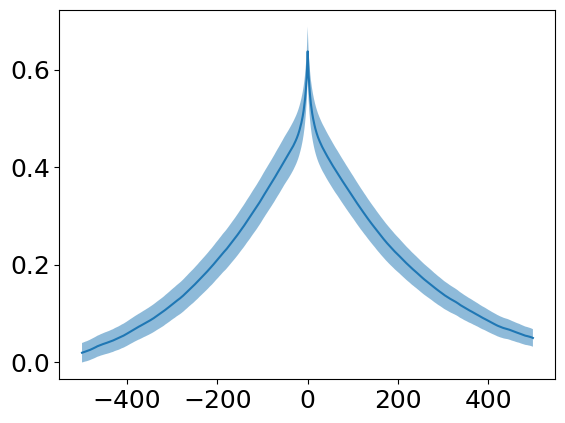

In [102]:
ind1 = 0
ind2 = 2
fig, ax = plt.subplots()

ax.plot(np.arange(1000) - 500, date_xcf["2025-02-18_09-19-26"]["avg"][ind1][ind2])

ax.fill_between(
    x=np.arange(1000) - 500,
    y1=date_xcf["2025-02-18_09-19-26"]["avg"][ind1][ind2]
    - date_xcf["2025-02-18_09-19-26"]["sem"][ind1][ind2],
    y2=date_xcf["2025-02-18_09-19-26"]["avg"][ind1][ind2]
    + date_xcf["2025-02-18_09-19-26"]["sem"][ind1][ind2],
    alpha=0.5,
)

In [ ]:
ref_ch_inds = np.array([1, 15, -2])
region = "hyp"
cond_date_xcf = {}
for cond in ["NREM", "REM", "WAKE"]:
    cond_date_xcf[cond] = {}
    for date, date_rec in rec_dict.items():
        reg_rec = date_rec[region]["raw"]
        ref_chs = depth_ordered_chs[::-1][ref_ch_inds]
        xcf = np.zeros(
            shape=(3, 32, session_dict[date].state_dict[cond]["times"].T.shape[0], 1000)
        )
        epoch_len = []
        for epoch, (start, end) in enumerate(
            session_dict[date].state_dict[cond]["times"].T
        ):
            tmp_rec = reg_rec.time_slice(start_time=start, end_time=end)
            epoch_len.append(tmp_rec.get_num_samples())
            ref_traces = np.concatenate(
                [
                    tmp_rec.get_traces(channel_ids=[ch], return_scaled=True)
                    for ch in ref_chs
                ],
                axis=1,
            ).T
            all_traces = np.concatenate(
                [
                    tmp_rec.get_traces(channel_ids=[ch], return_scaled=True)
                    for ch in depth_ordered_chs[::-1]
                ],
                axis=1,
            ).T
            for i, ref in enumerate(ref_traces):
                for j, targ in enumerate(all_traces):
                    bkwds = sm.tsa.ccf(targ, ref, adjusted=False, nlags=501)[::-1]
                    fwds = sm.tsa.ccf(ref, targ, adjusted=False, nlags=500)
                    ccf_output = np.r_[bkwds[:-1], fwds]
                    xcf[i, j, epoch] = ccf_output
        epoch_len = np.array(epoch_len)
        epoch_len = epoch_len / epoch_len.max()
        masked_xcf = np.ma.masked_array(xcf, np.isnan(xcf))
        avg_nan_xcf = np.ma.average(masked_xcf, axis=2, weights=epoch_len)
        weighted_xcf = avg_nan_xcf.filled(np.nan)
        # weighted_xcf = np.average(xcf, axis=2, weights=epoch_len)
        cond_date_xcf[cond][date] = weighted_xcf

In [14]:
Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/ch_xcf/").mkdir(
    parents=True, exist_ok=True
)
for cond, date_xcf in cond_date_xcf.items():
    for date, xcf in date_xcf.items():
        np.savez(
            Path(
                "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/ch_xcf/",
                f"{cond}_{date}_hyp_raw_xcf.npz",
            ),
            xcf=xcf,
        )

In [104]:
max_corr = {
    date: np.array([[targ[500] for targ in ref] for ref in xcf["avg"]])
    for date, xcf in date_xcf.items()
}
avg_max_corr = {
    date: np.array(
        [[np.median(targ[500 - 10 : 500 + 10]) for targ in ref] for ref in xcf["avg"]]
    )
    for date, xcf in date_xcf.items()
}
deflections = {}
for date, tmp_max_corr in max_corr.items():
    tmp_avg_max_corr = avg_max_corr[date]
    deflections[date] = {}
    for tmp_max, tmp_avg, ref_area in zip(
        tmp_max_corr, tmp_avg_max_corr, ["top", "middle", "bottom"]
    ):
        tmp_defl = []
        for ch_max, ch_avg in zip(tmp_max, tmp_avg):
            if ch_max > ch_avg:
                defl = 1
            elif ch_max < ch_avg:
                defl = -1
            else:
                defl = 0
            tmp_defl.append(defl)
        deflections[date][ref_area] = np.array(tmp_defl)

### Plotting

In [105]:
exp_dates = {
    exp: [
        date
        for sub_dict in full_dict.values()
        for date, exp_cond in zip(sub_dict["dates"], sub_dict["condition"])
        if exp_cond == exp
    ]
    for exp in ["none", "sleep", "food"]
}

In [ ]:
# for (cond, max_corr_cond), avg_max_corr_cond, cond_defl in zip(
#     max_corr.items(), avg_max_corr.values(), deflections.values()
# ):

#     for exp_cond, dates in exp_dates.items():
#         fig, axs = plt.subplots(
#             3,
#             len(dates),
#             figsize=(len(dates) * 4, 8),
#             sharex=True,
#             sharey=True,
#             constrained_layout=True,
#         )
#         for date, tmp_axs in zip(dates, axs.T):
#             max_corr_date = max_corr_cond[date]
#             avg_max_corr_date = avg_max_corr_cond[date]
#             date_defl = cond_defl[date]

#             for ref_max, ref_avg, ax, ref_area in zip(
#                 max_corr_date,
#                 avg_max_corr_date,
#                 tmp_axs.ravel(),
#                 ["top", "middle", "bottom"],
#             ):
#                 ax.plot(np.arange(1, len(depth_ordered_chs) + 1), ref_max)
#                 #     ax.plot(
#                 #         np.arange(1, len(depth_ordered_chs) + 1),
#                 #         ref_avg,
#                 #     )
#                 # ax.plot(
#                 #     np.arange(1, len(depth_ordered_chs) + 1),
#                 #     ref_max - ref_avg,
#                 # )
#                 ax.plot(
#                     np.arange(1, len(depth_ordered_chs) + 1),
#                     (date_defl[ref_area] / 11),
#                     ls="",
#                     marker="x",
#                     c="r",
#                 )
#                 ax.axhline(y=0, ls="--", c="k")
#                 ax.set_xticks(np.arange(0, len(depth_ordered_chs) + 1, 8))
#             tmp_axs[0].set_title(date)
#         for ax, area in zip(axs[:, 0], ["top", "middle", "bottom"]):
#             ax.set_ylabel(area)
#             # ax.set_ylim([-0.5, 1.5])
#         fig.supxlabel("Channel Depth Index", y=-0.05, fontsize=20)
#         fig.suptitle(f"Max Cross-Corr Coeff - {exp_cond} - {cond}")

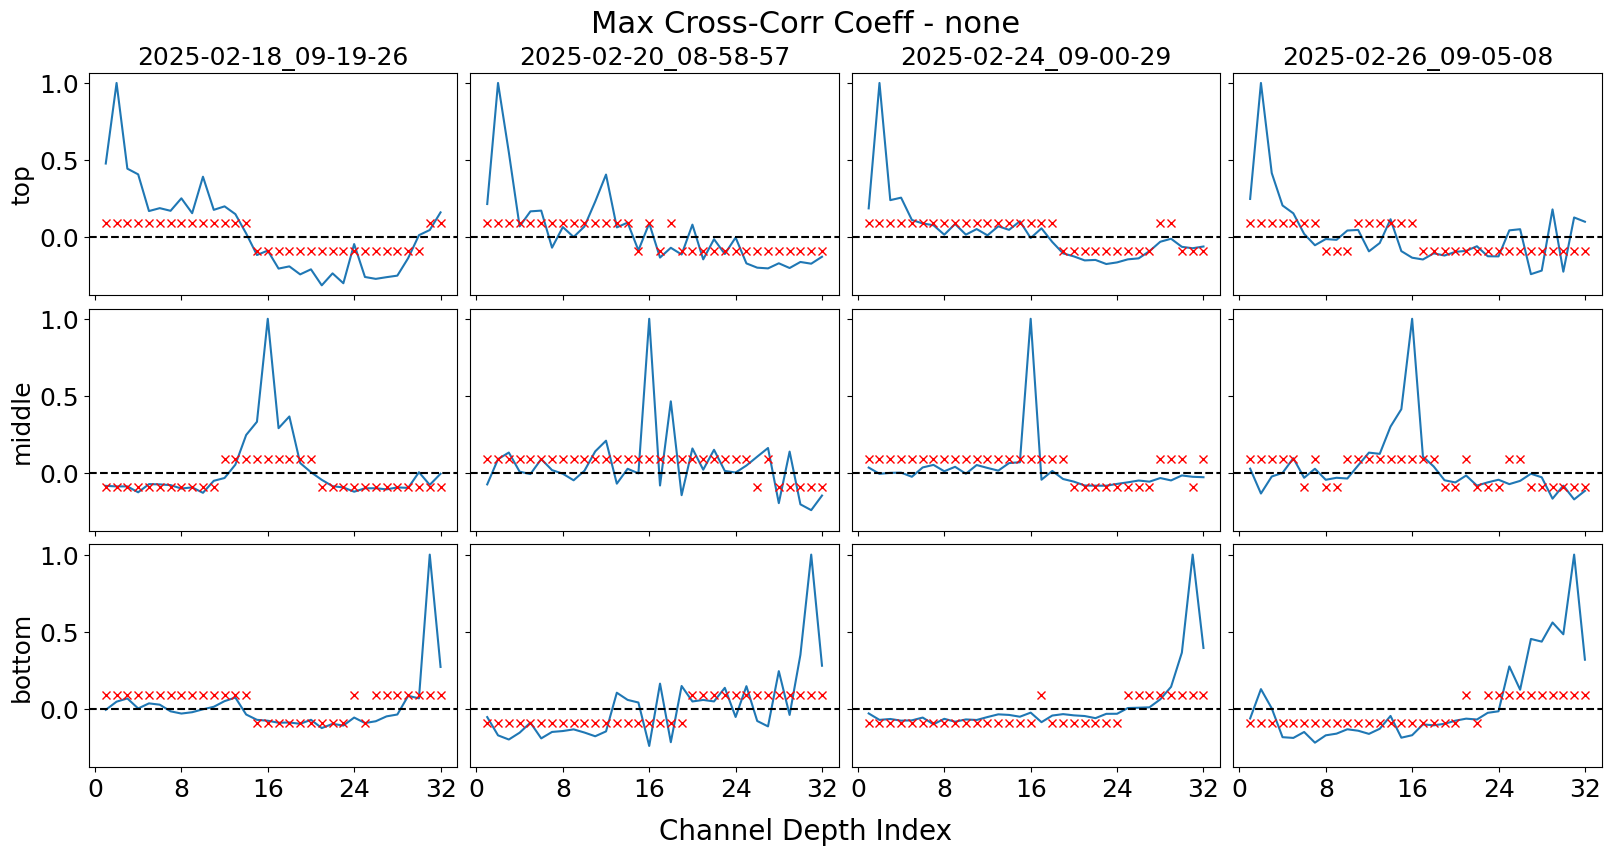

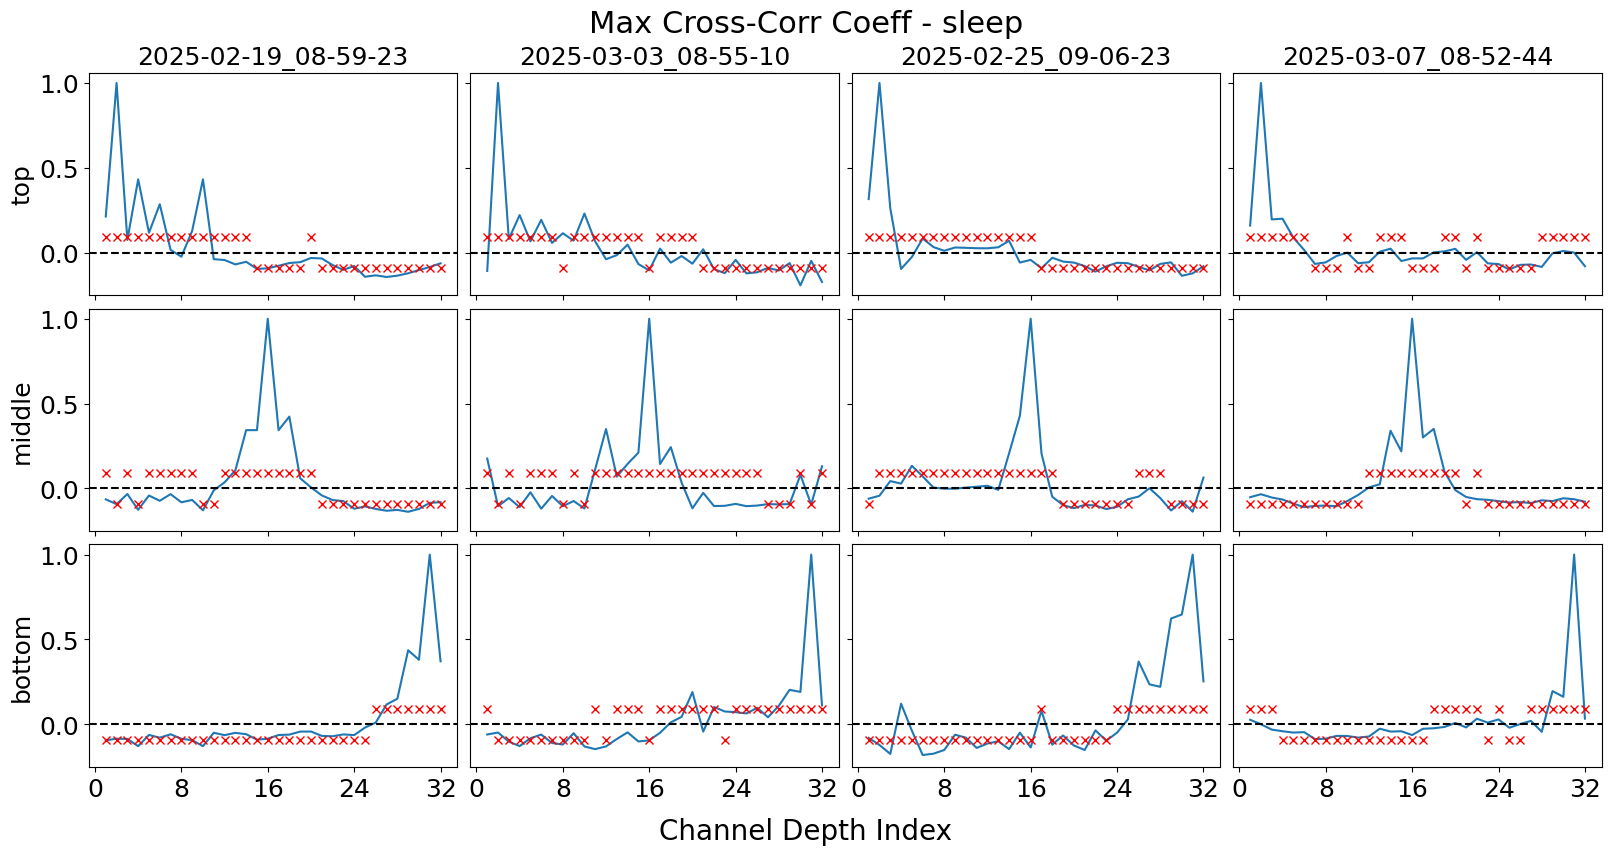

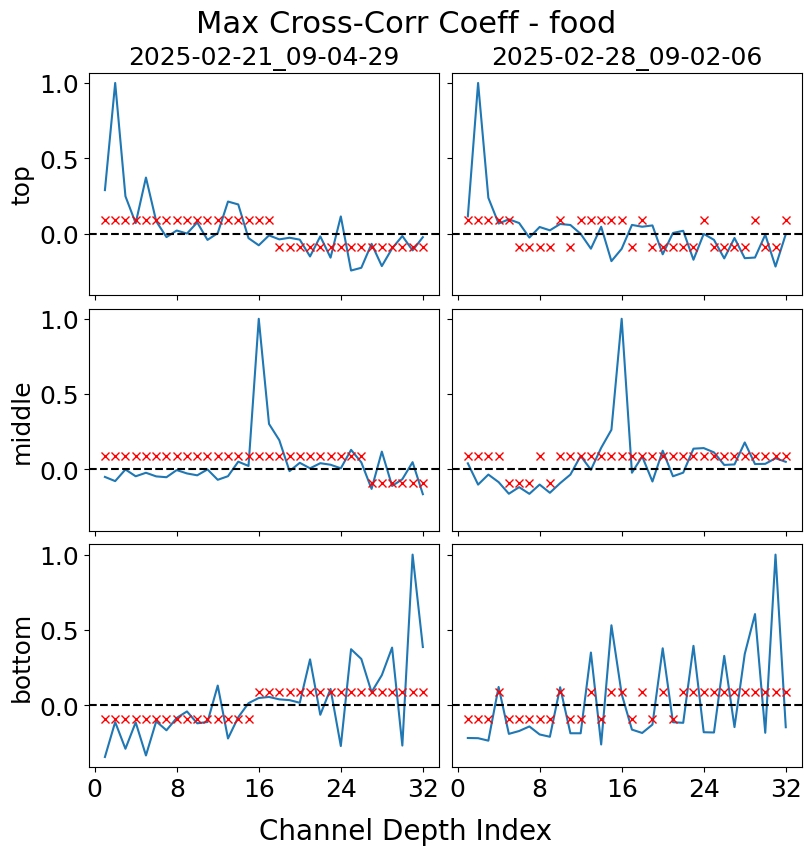

In [85]:
# for (cond, max_corr_cond), avg_max_corr_cond, cond_defl in zip(
#     max_corr.items(), avg_max_corr.values(), deflections.values()
# ):

for exp_cond, dates in exp_dates.items():
    fig, axs = plt.subplots(
        3,
        len(dates),
        figsize=(len(dates) * 4, 8),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    for date, tmp_axs in zip(dates, axs.T):
        max_corr_date = max_corr[date]
        avg_max_corr_date = avg_max_corr[date]
        date_defl = deflections[date]

        for ref_max, ref_avg, ax, ref_area in zip(
            max_corr_date,
            avg_max_corr_date,
            tmp_axs.ravel(),
            ["top", "middle", "bottom"],
        ):
            ax.plot(np.arange(1, len(depth_ordered_chs) + 1), ref_max)
            #     ax.plot(
            #         np.arange(1, len(depth_ordered_chs) + 1),
            #         ref_avg,
            #     )
            # ax.plot(
            #     np.arange(1, len(depth_ordered_chs) + 1),
            #     ref_max - ref_avg,
            # )
            ax.plot(
                np.arange(1, len(depth_ordered_chs) + 1),
                (date_defl[ref_area] / 11),
                ls="",
                marker="x",
                c="r",
            )
            ax.axhline(y=0, ls="--", c="k")
            ax.set_xticks(np.arange(0, len(depth_ordered_chs) + 1, 8))
        tmp_axs[0].set_title(date)
    for ax, area in zip(axs[:, 0], ["top", "middle", "bottom"]):
        ax.set_ylabel(area)
        # ax.set_ylim([-0.5, 1.5])
    fig.supxlabel("Channel Depth Index", y=-0.05, fontsize=20)
    fig.suptitle(f"Max Cross-Corr Coeff - {exp_cond}")

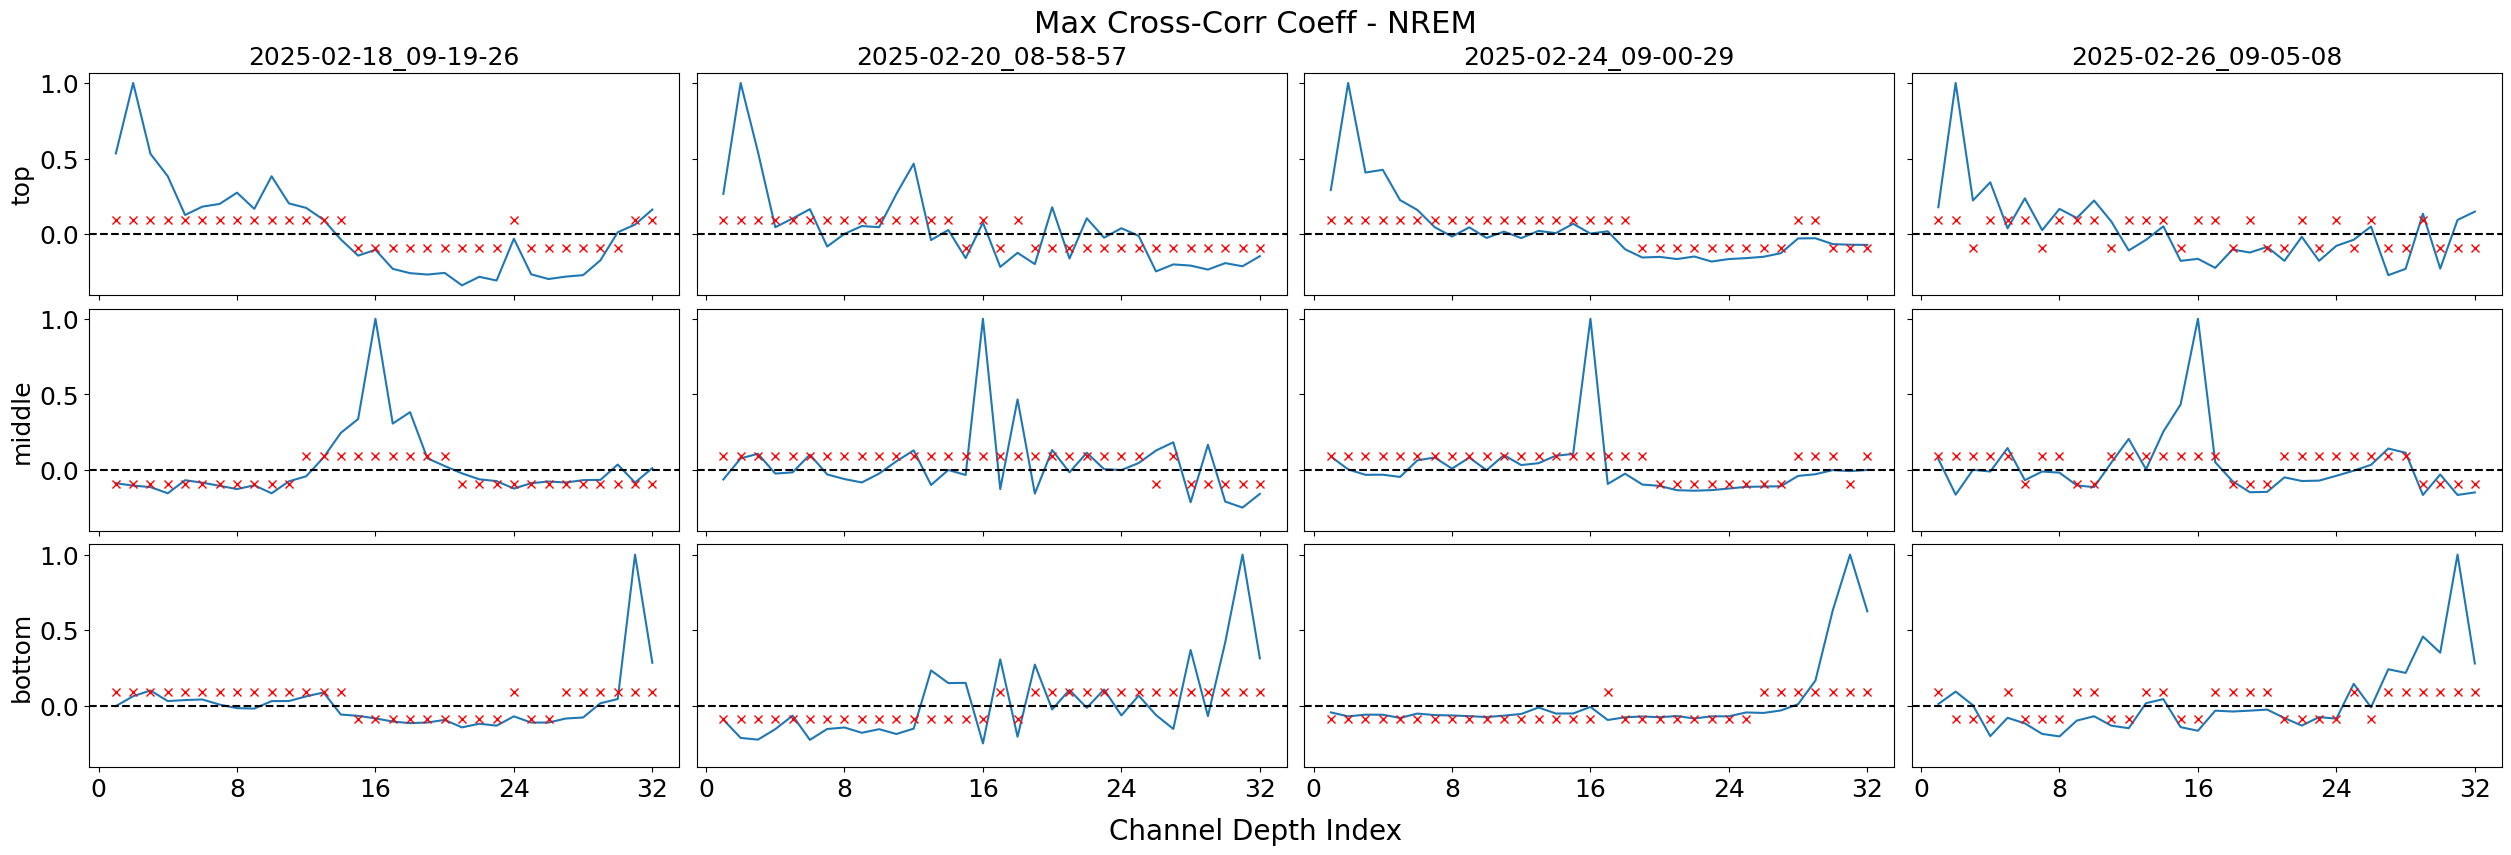

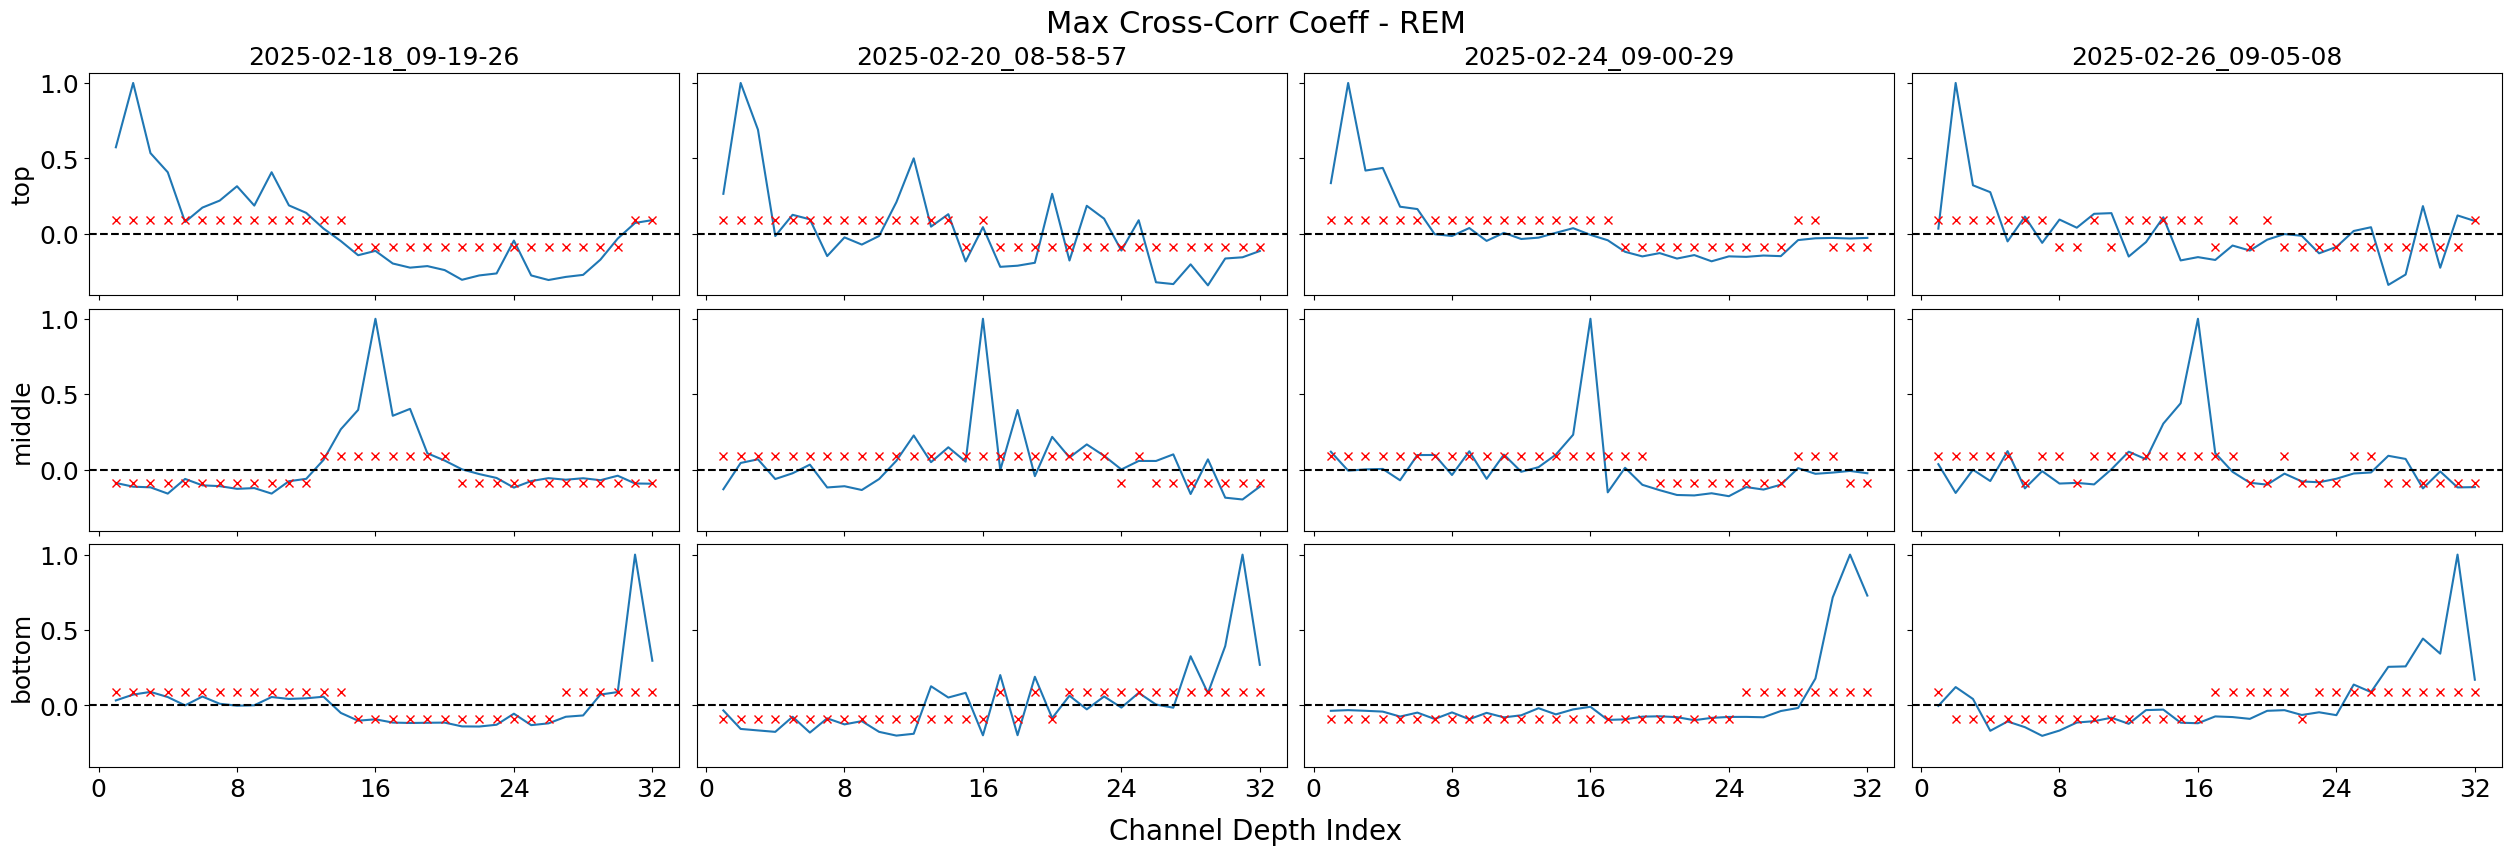

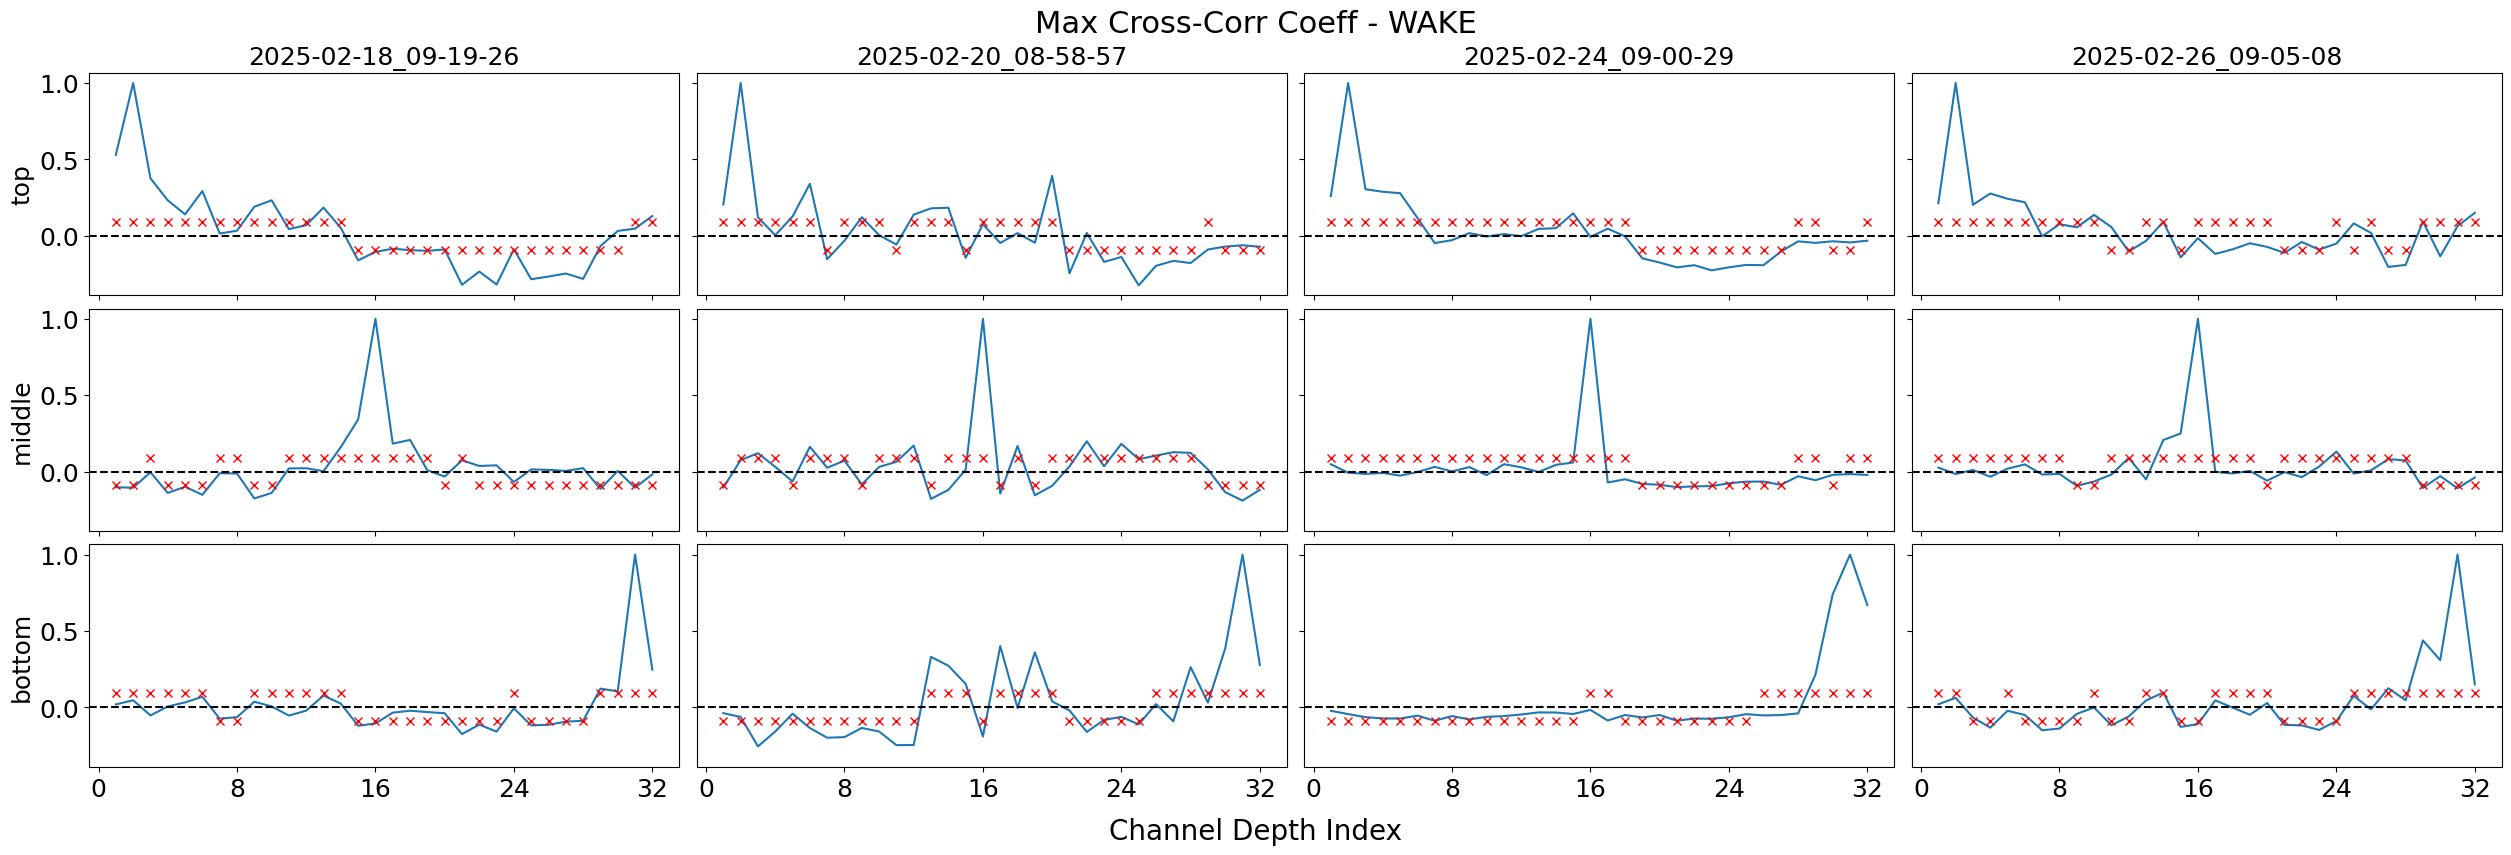

In [ ]:
for (cond, max_corr_cond), avg_max_corr_cond, cond_defl in zip(
    max_corr.items(), avg_max_corr.values(), deflections.values()
):
    fig, axs = plt.subplots(
        3, 6, figsize=(25, 8), sharex=True, sharey=True, constrained_layout=True
    )

    for (date, max_corr_date), avg_max_corr_date, date_defl, tmp_axs in zip(
        max_corr_cond.items(), avg_max_corr_cond.values(), cond_defl.values(), axs.T
    ):
        for ref_max, ref_avg, ax, ref_area in zip(
            max_corr_date,
            avg_max_corr_date,
            tmp_axs.ravel(),
            ["top", "middle", "bottom"],
        ):
            ax.plot(np.arange(1, len(depth_ordered_chs) + 1), ref_max)
            #     ax.plot(
            #         np.arange(1, len(depth_ordered_chs) + 1),
            #         ref_avg,
            #     )
            # ax.plot(
            #     np.arange(1, len(depth_ordered_chs) + 1),
            #     ref_max - ref_avg,
            # )
            ax.plot(
                np.arange(1, len(depth_ordered_chs) + 1),
                (date_defl[ref_area] / 11),
                ls="",
                marker="x",
                c="r",
            )
            ax.axhline(y=0, ls="--", c="k")
            ax.set_xticks(np.arange(0, len(depth_ordered_chs) + 1, 8))
        tmp_axs[0].set_title(date)
    for ax, area in zip(axs[:, 0], ["top", "middle", "bottom"]):
        ax.set_ylabel(area)
        # ax.set_ylim([-0.5, 1.5])
    fig.supxlabel("Channel Depth Index", y=-0.05, fontsize=20)
    fig.suptitle(f"Max Cross-Corr Coeff - {cond}")

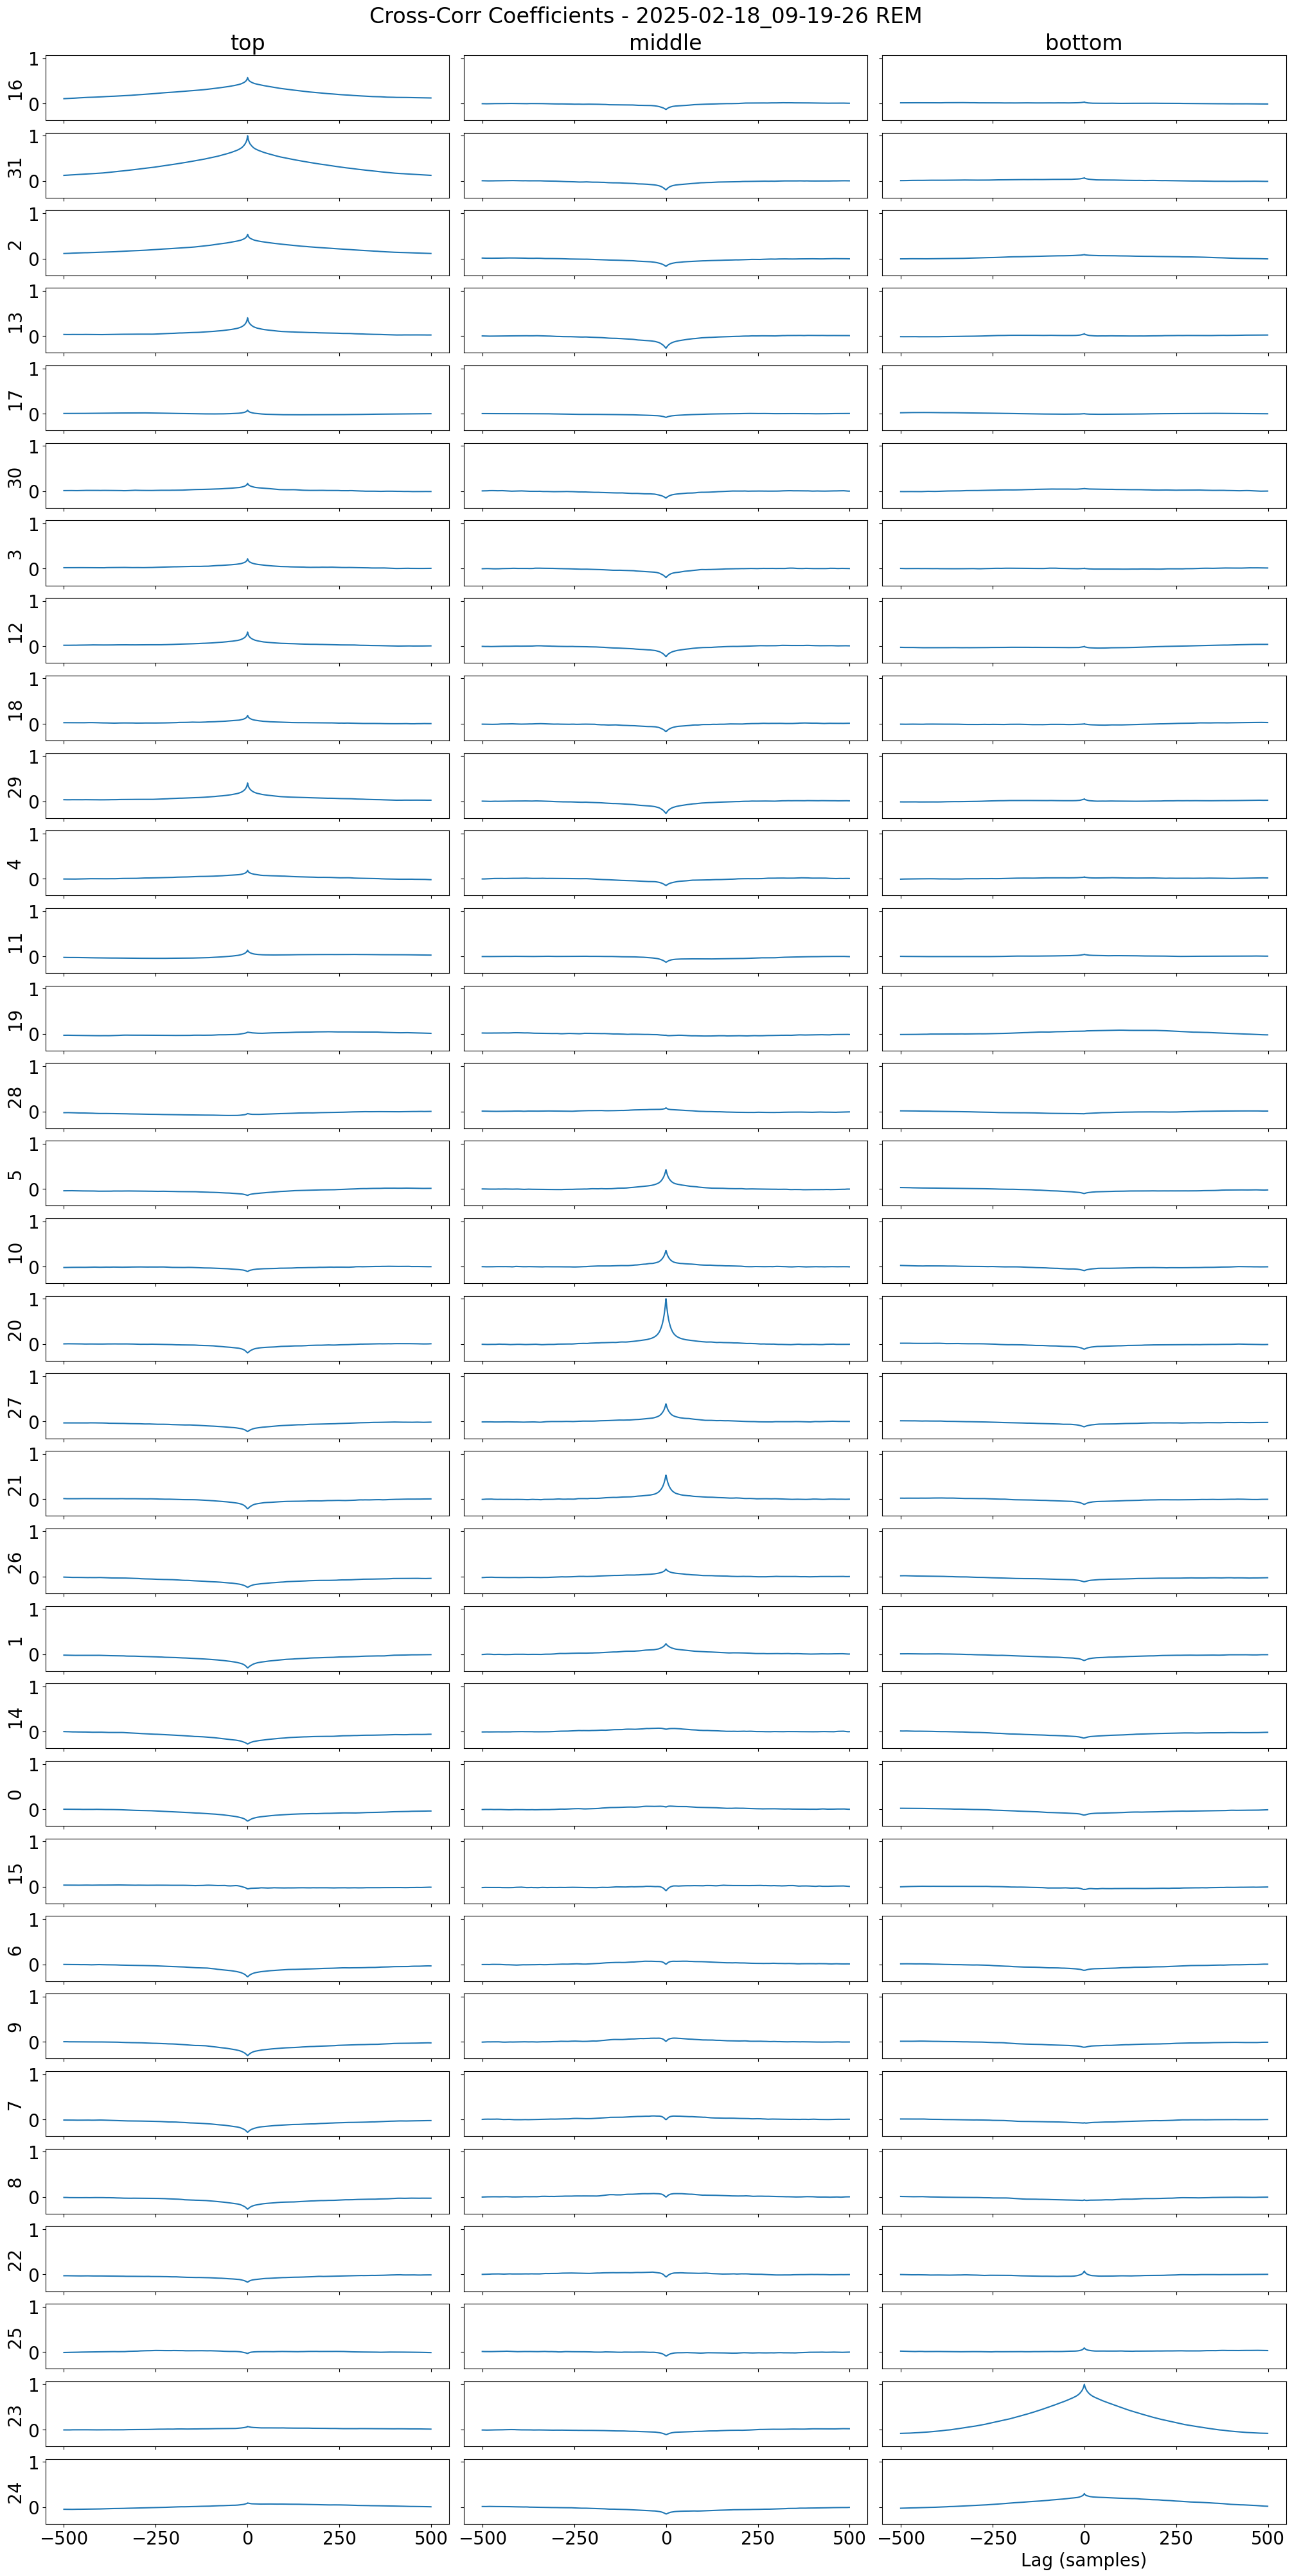

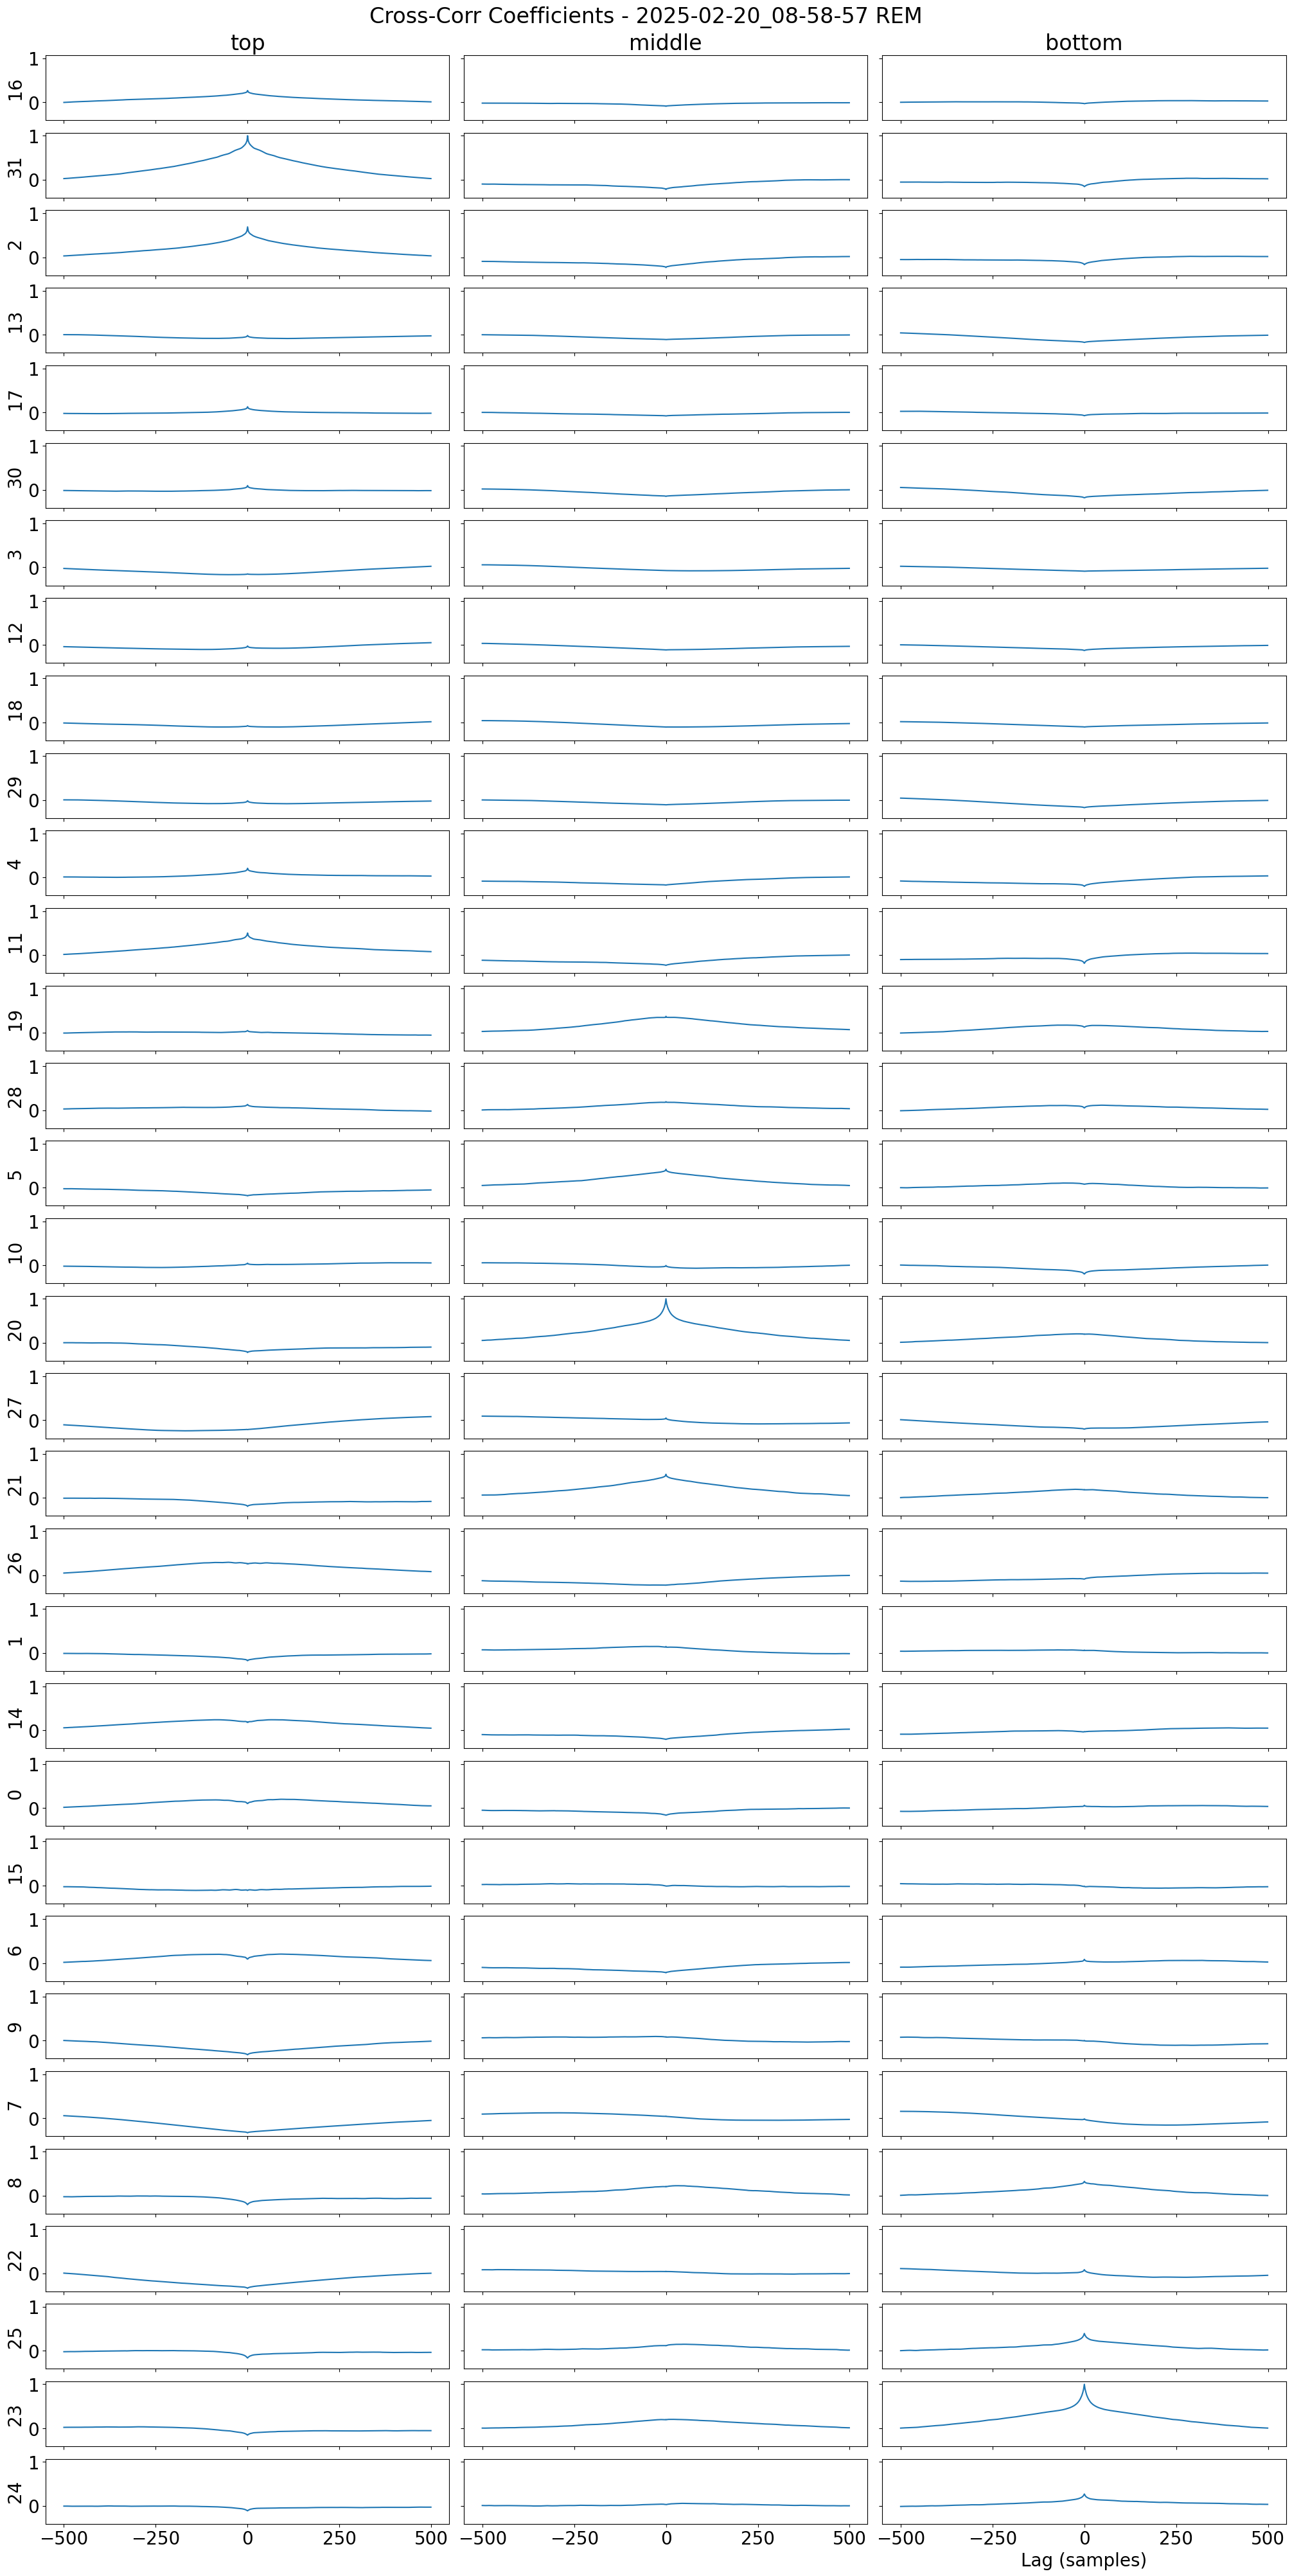

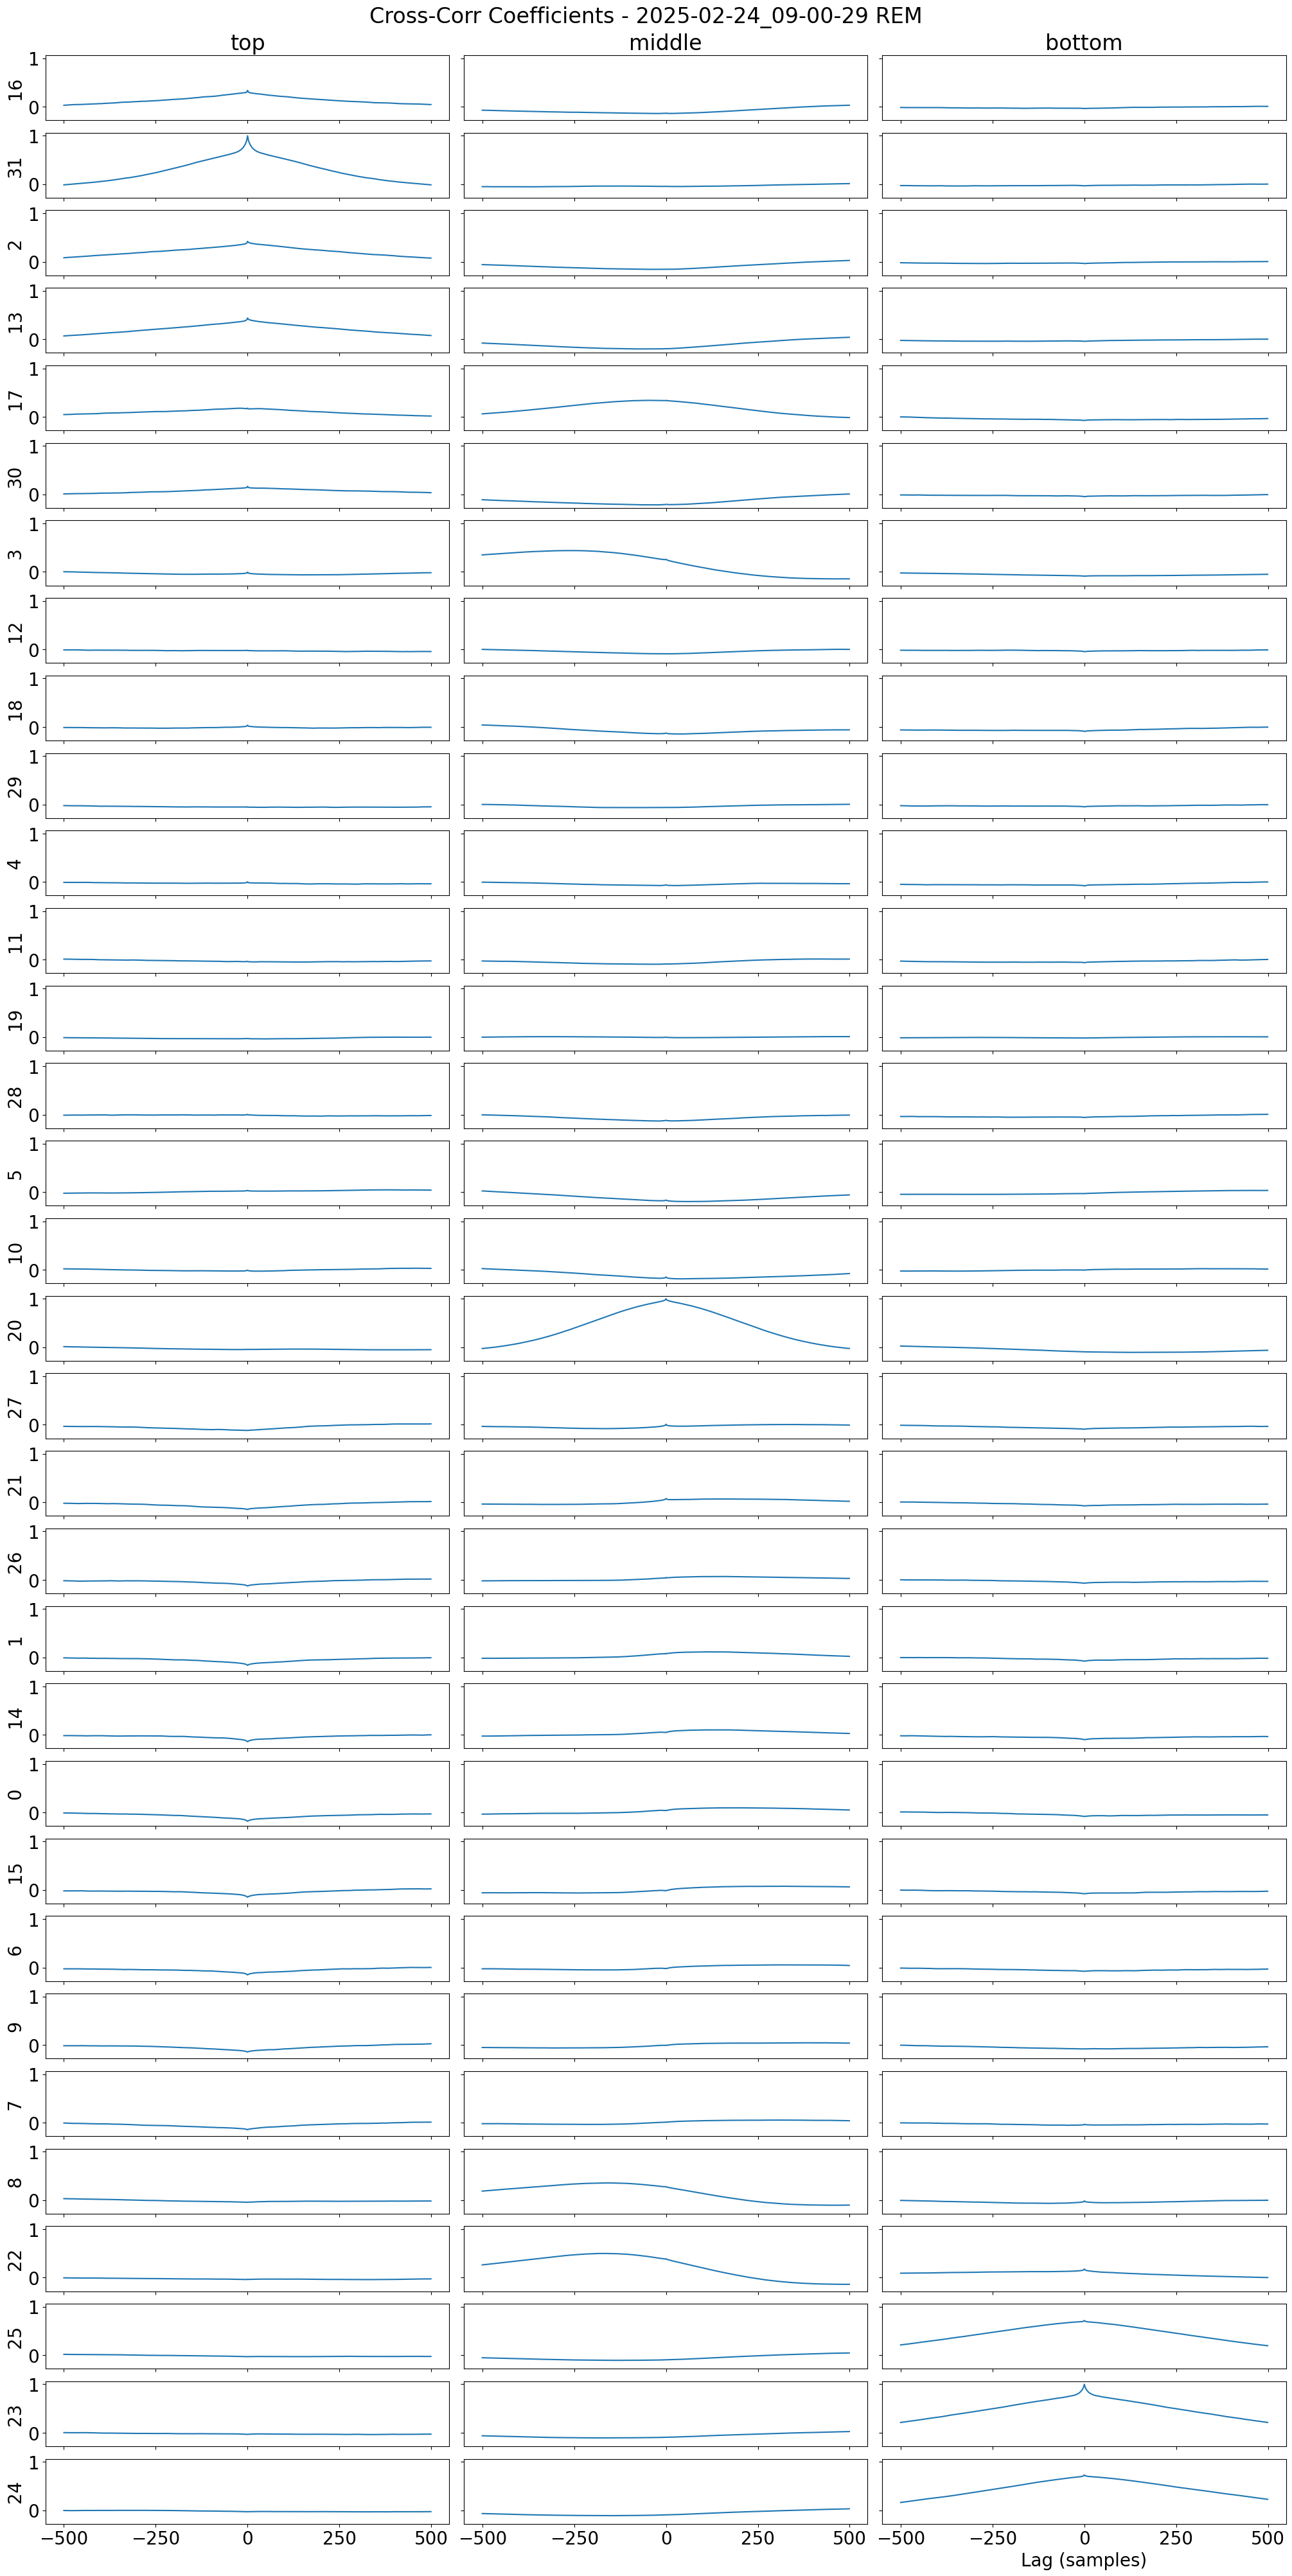

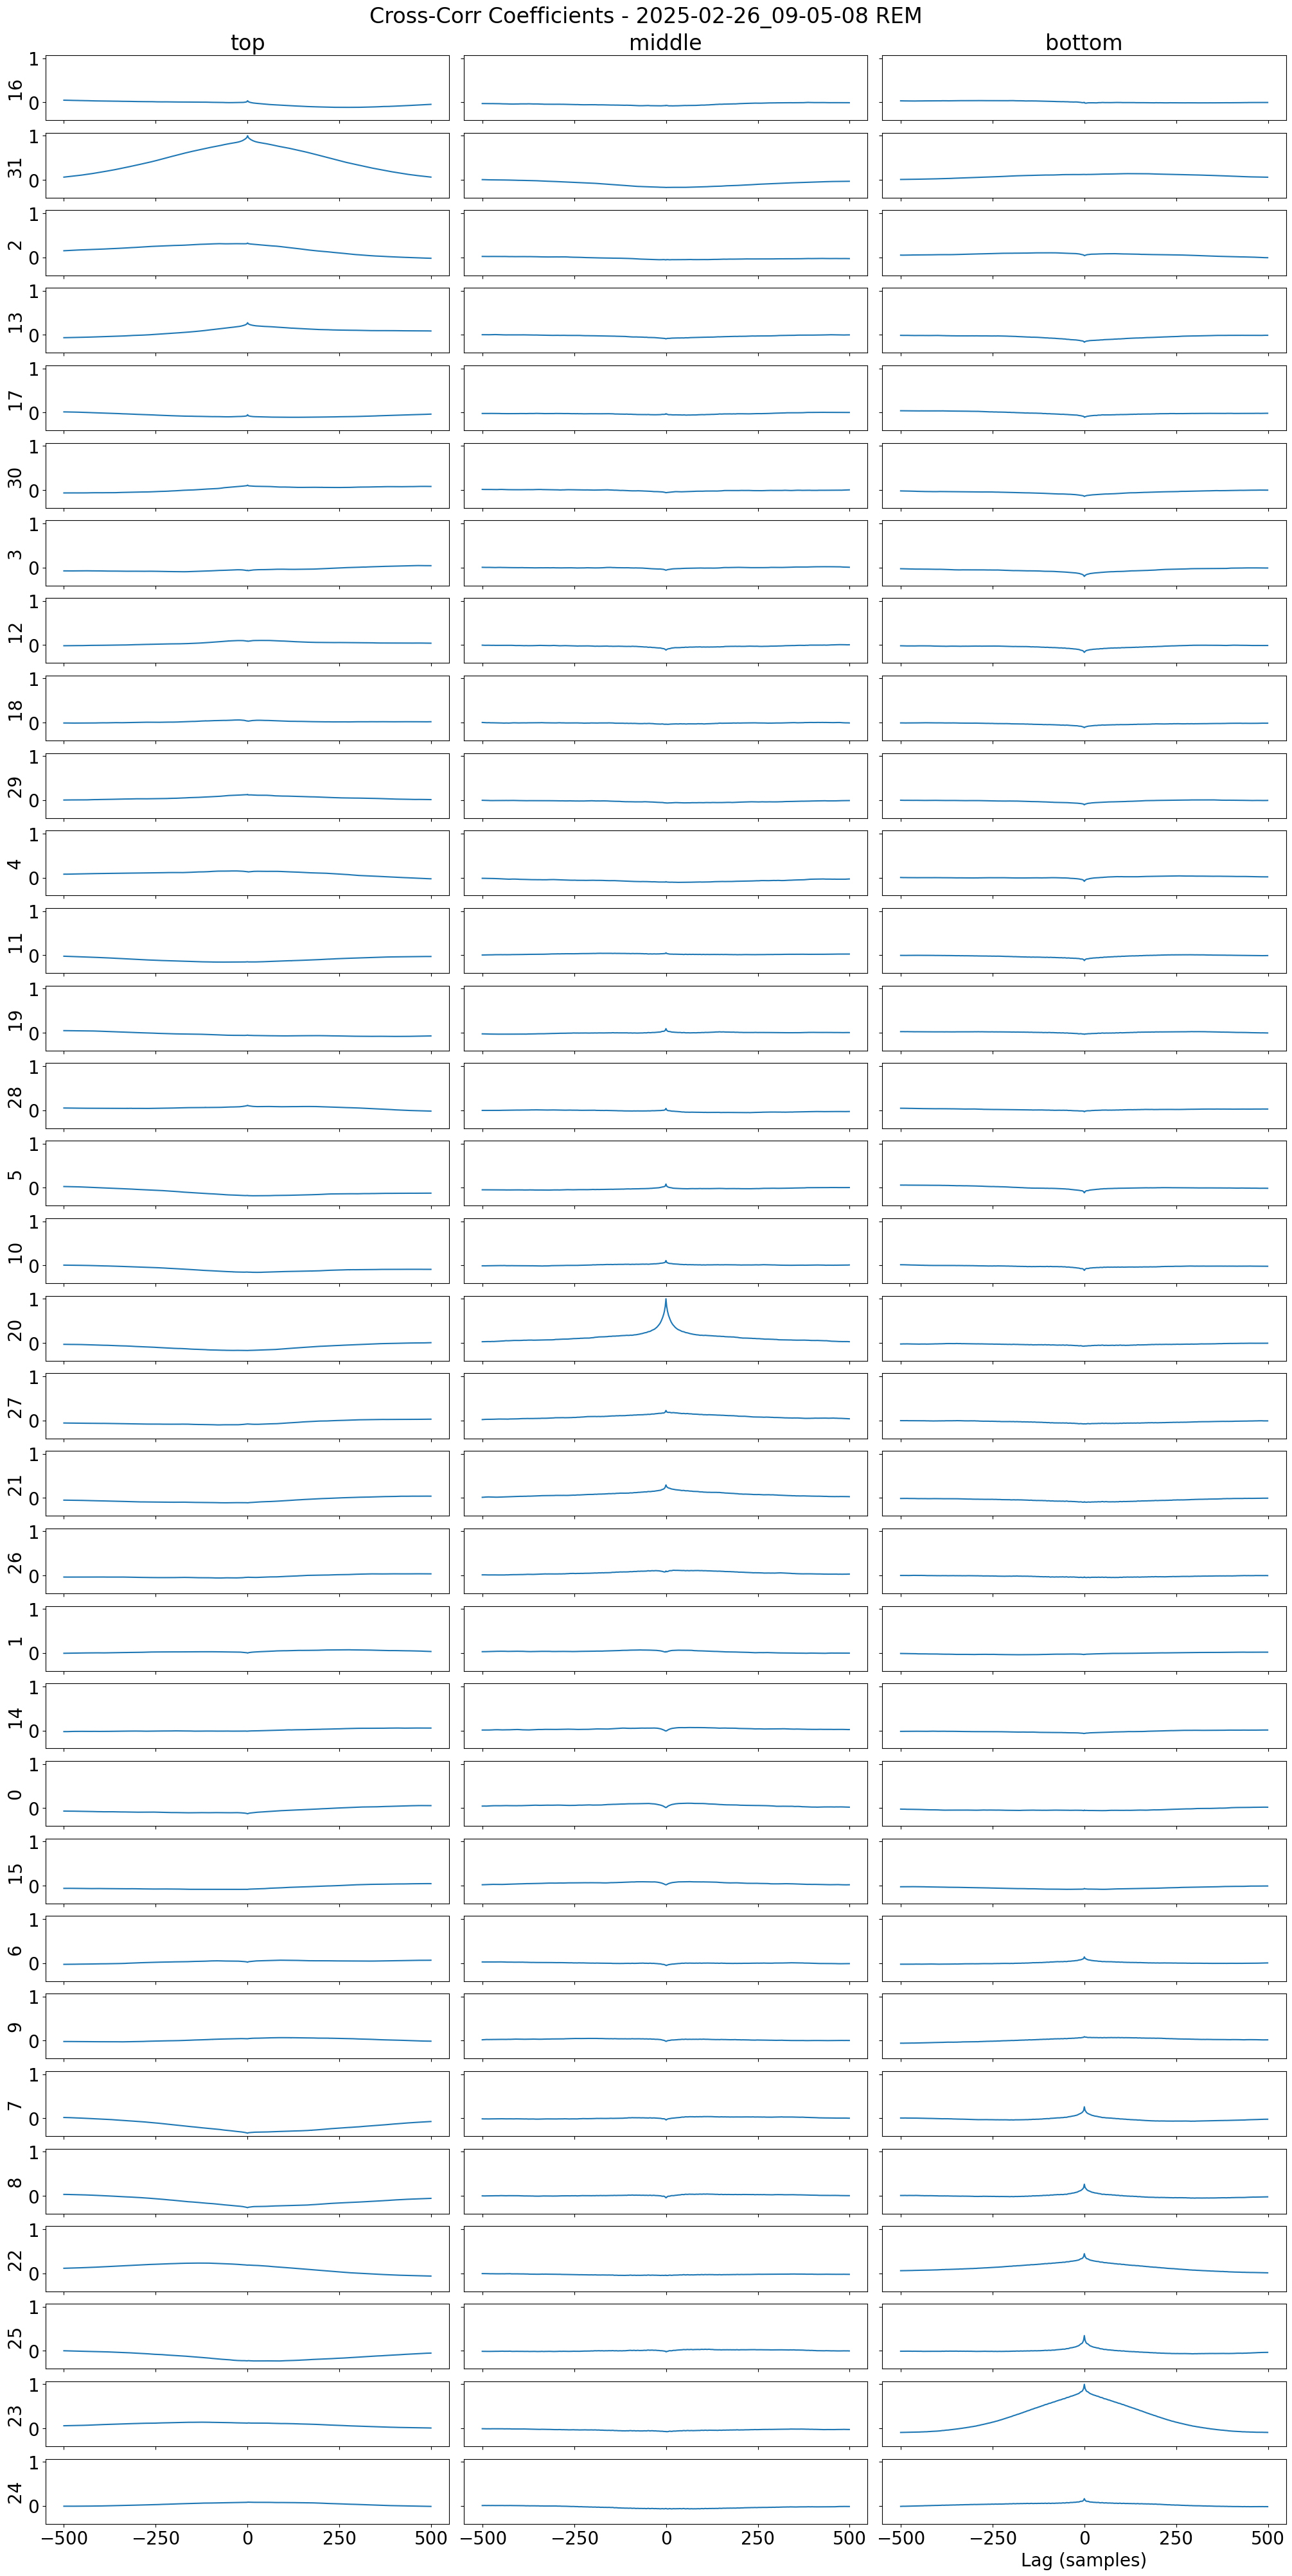

In [70]:
for date, xcf in date_xcf.items():
    fig, axs = plt.subplots(
        32, 3, figsize=(20, 40), sharex=True, sharey=True, constrained_layout=True
    )
    ticks = np.arange(1000) - 500
    for (i, ref), ref_zone in zip(enumerate(xcf), ["top", "middle", "bottom"]):
        sub_ax = axs[:, i]
        sub_ax[0].set_title(ref_zone)
        for j, ch_corr in enumerate(ref):
            sub_ax[j].plot(ticks, ch_corr)
            if i == 0:
                sub_ax[j].set_ylabel(depth_ordered_chs[::-1][j])
    _ = axs[-1, -1].set_xticks(ticks=[-500, -250, 0, 250, 500])
    _ = axs[-1, -1].set_xlabel("Lag (samples)")
    fig.suptitle(f"Cross-Corr Coefficients - {date} REM")

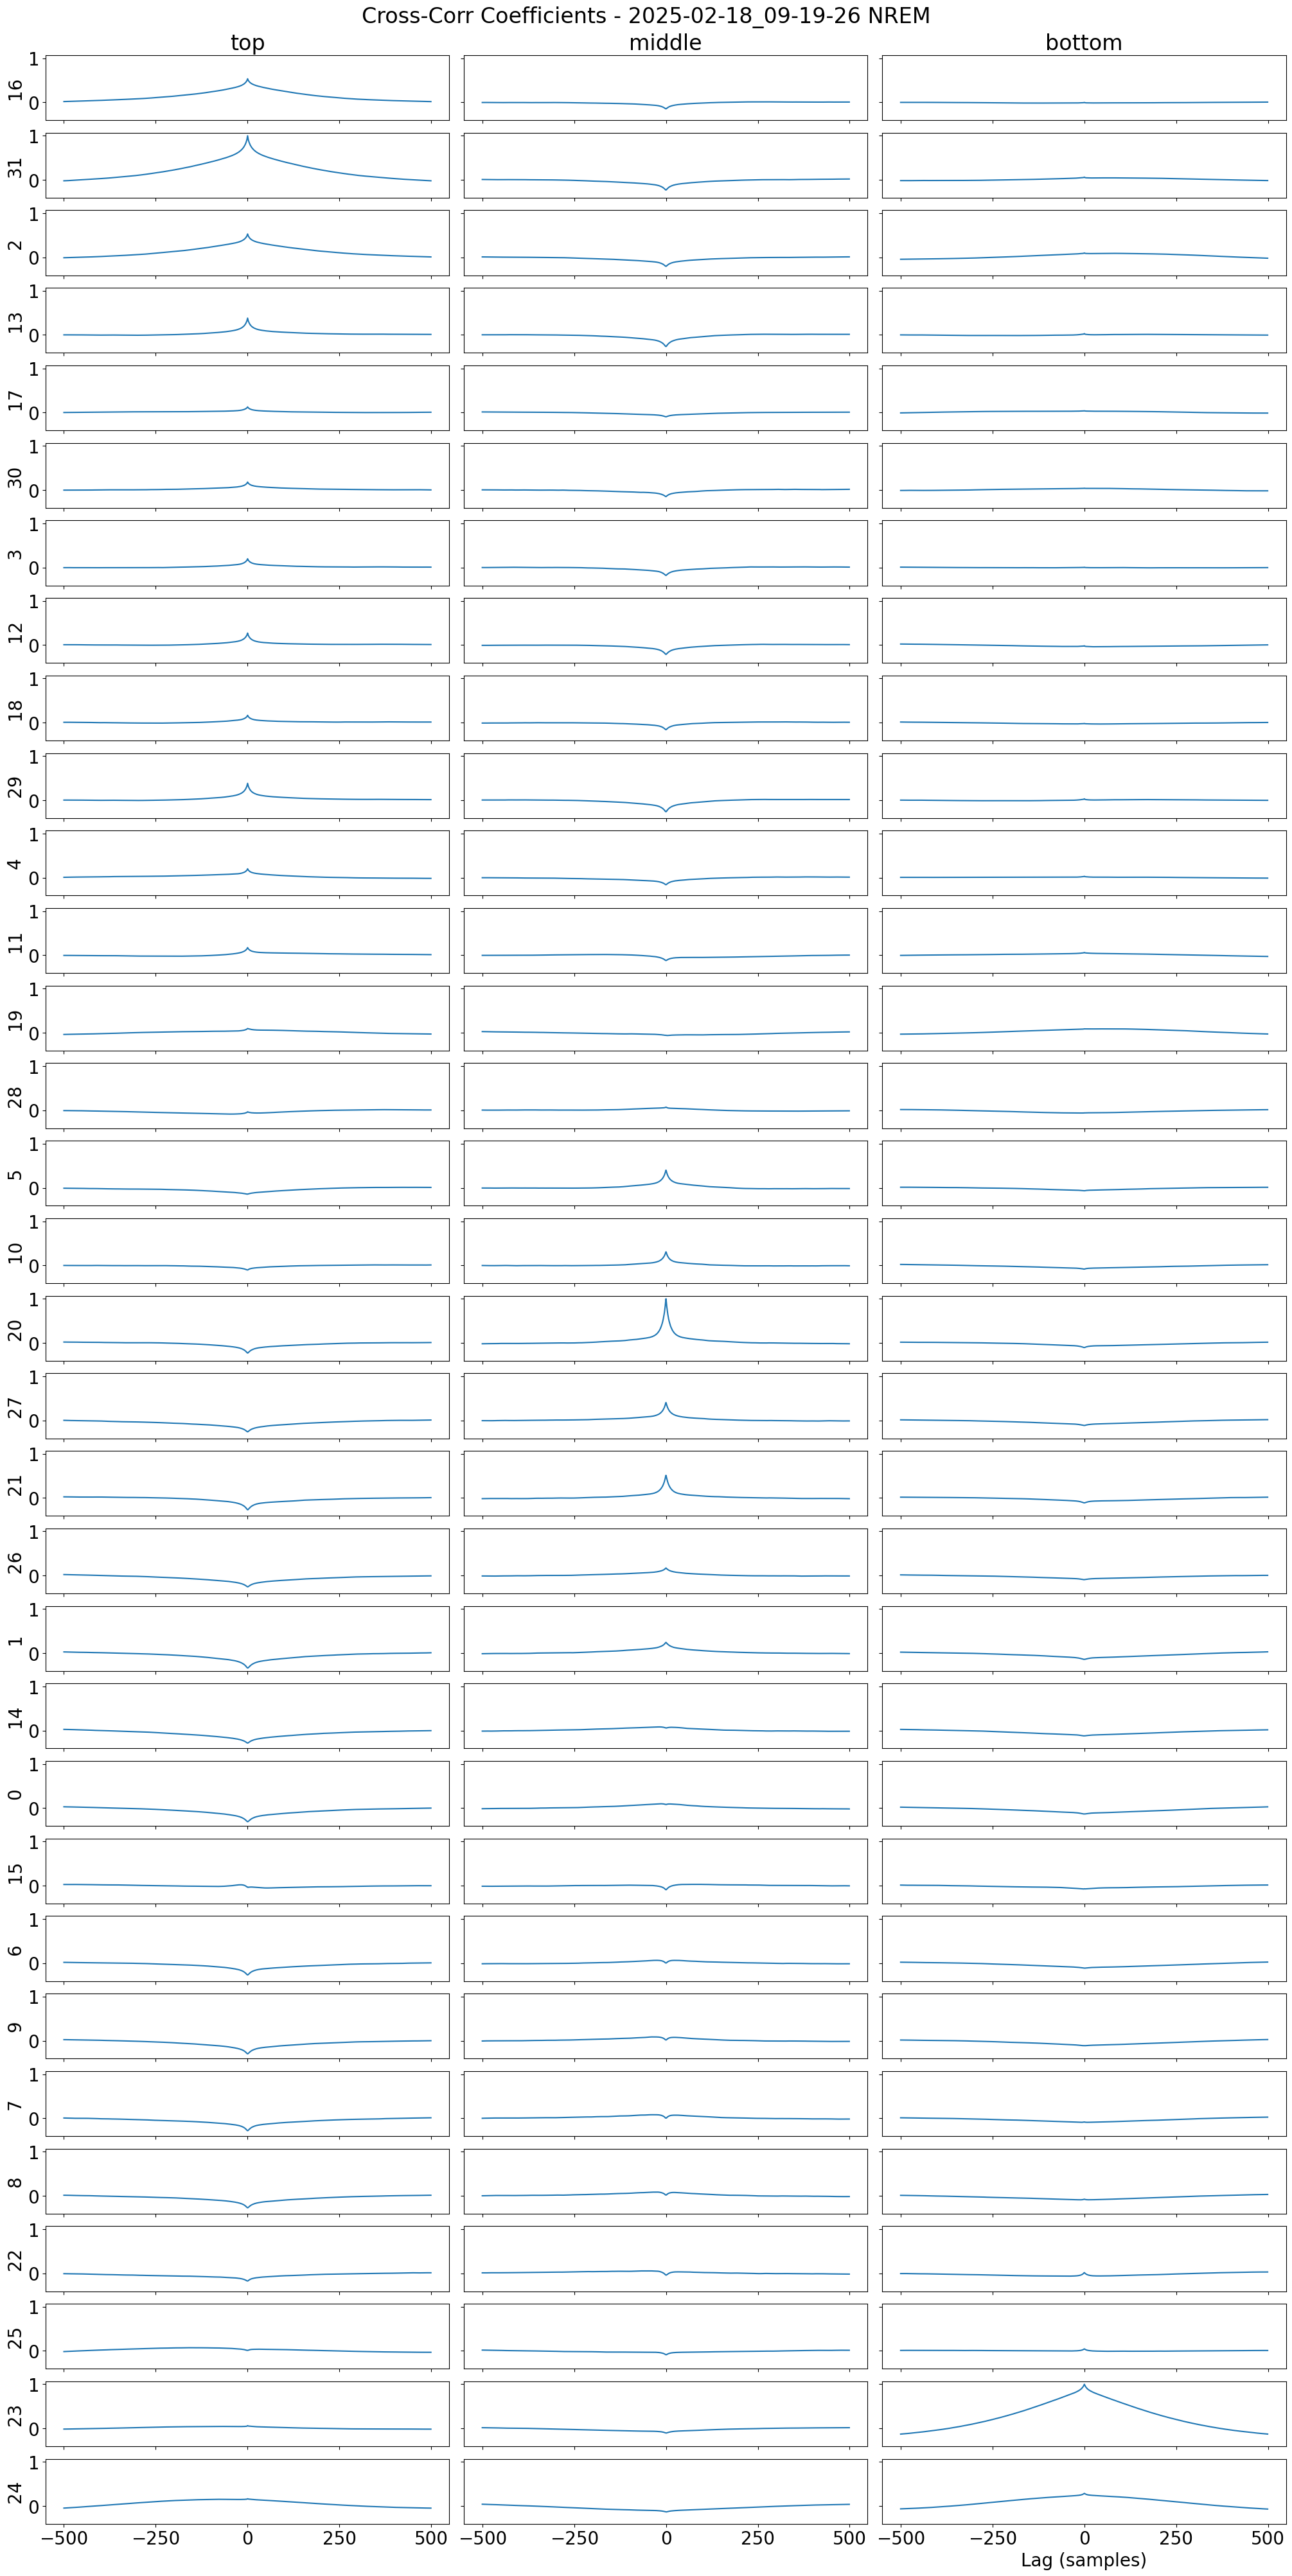

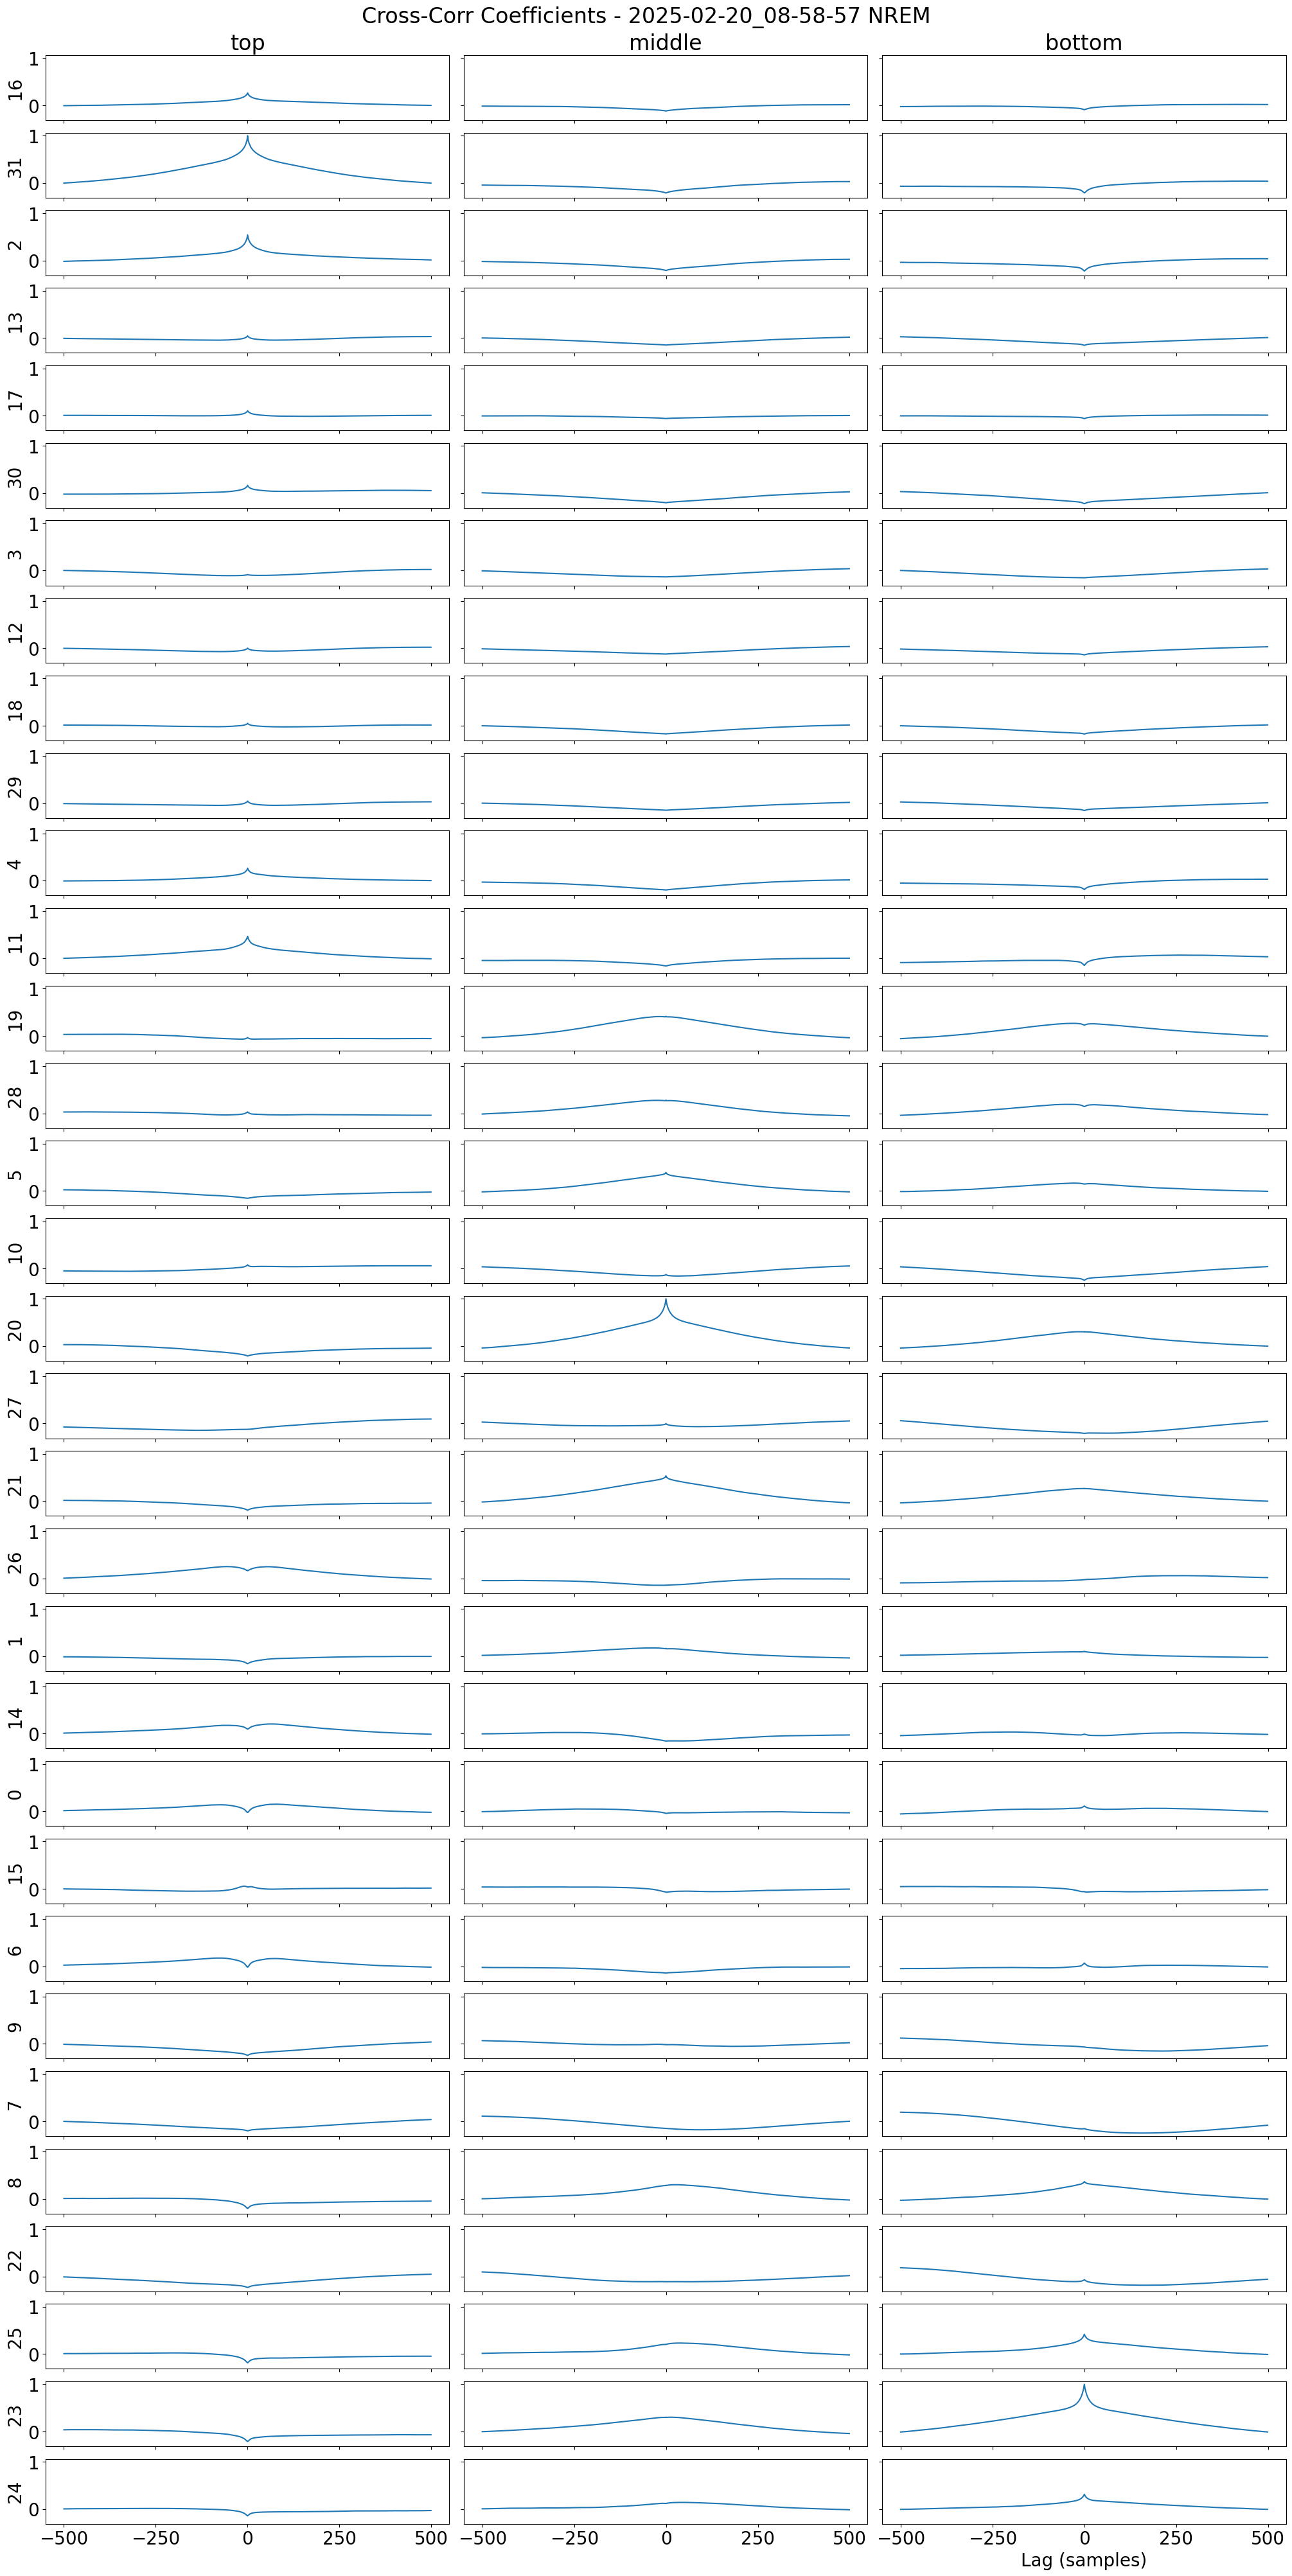

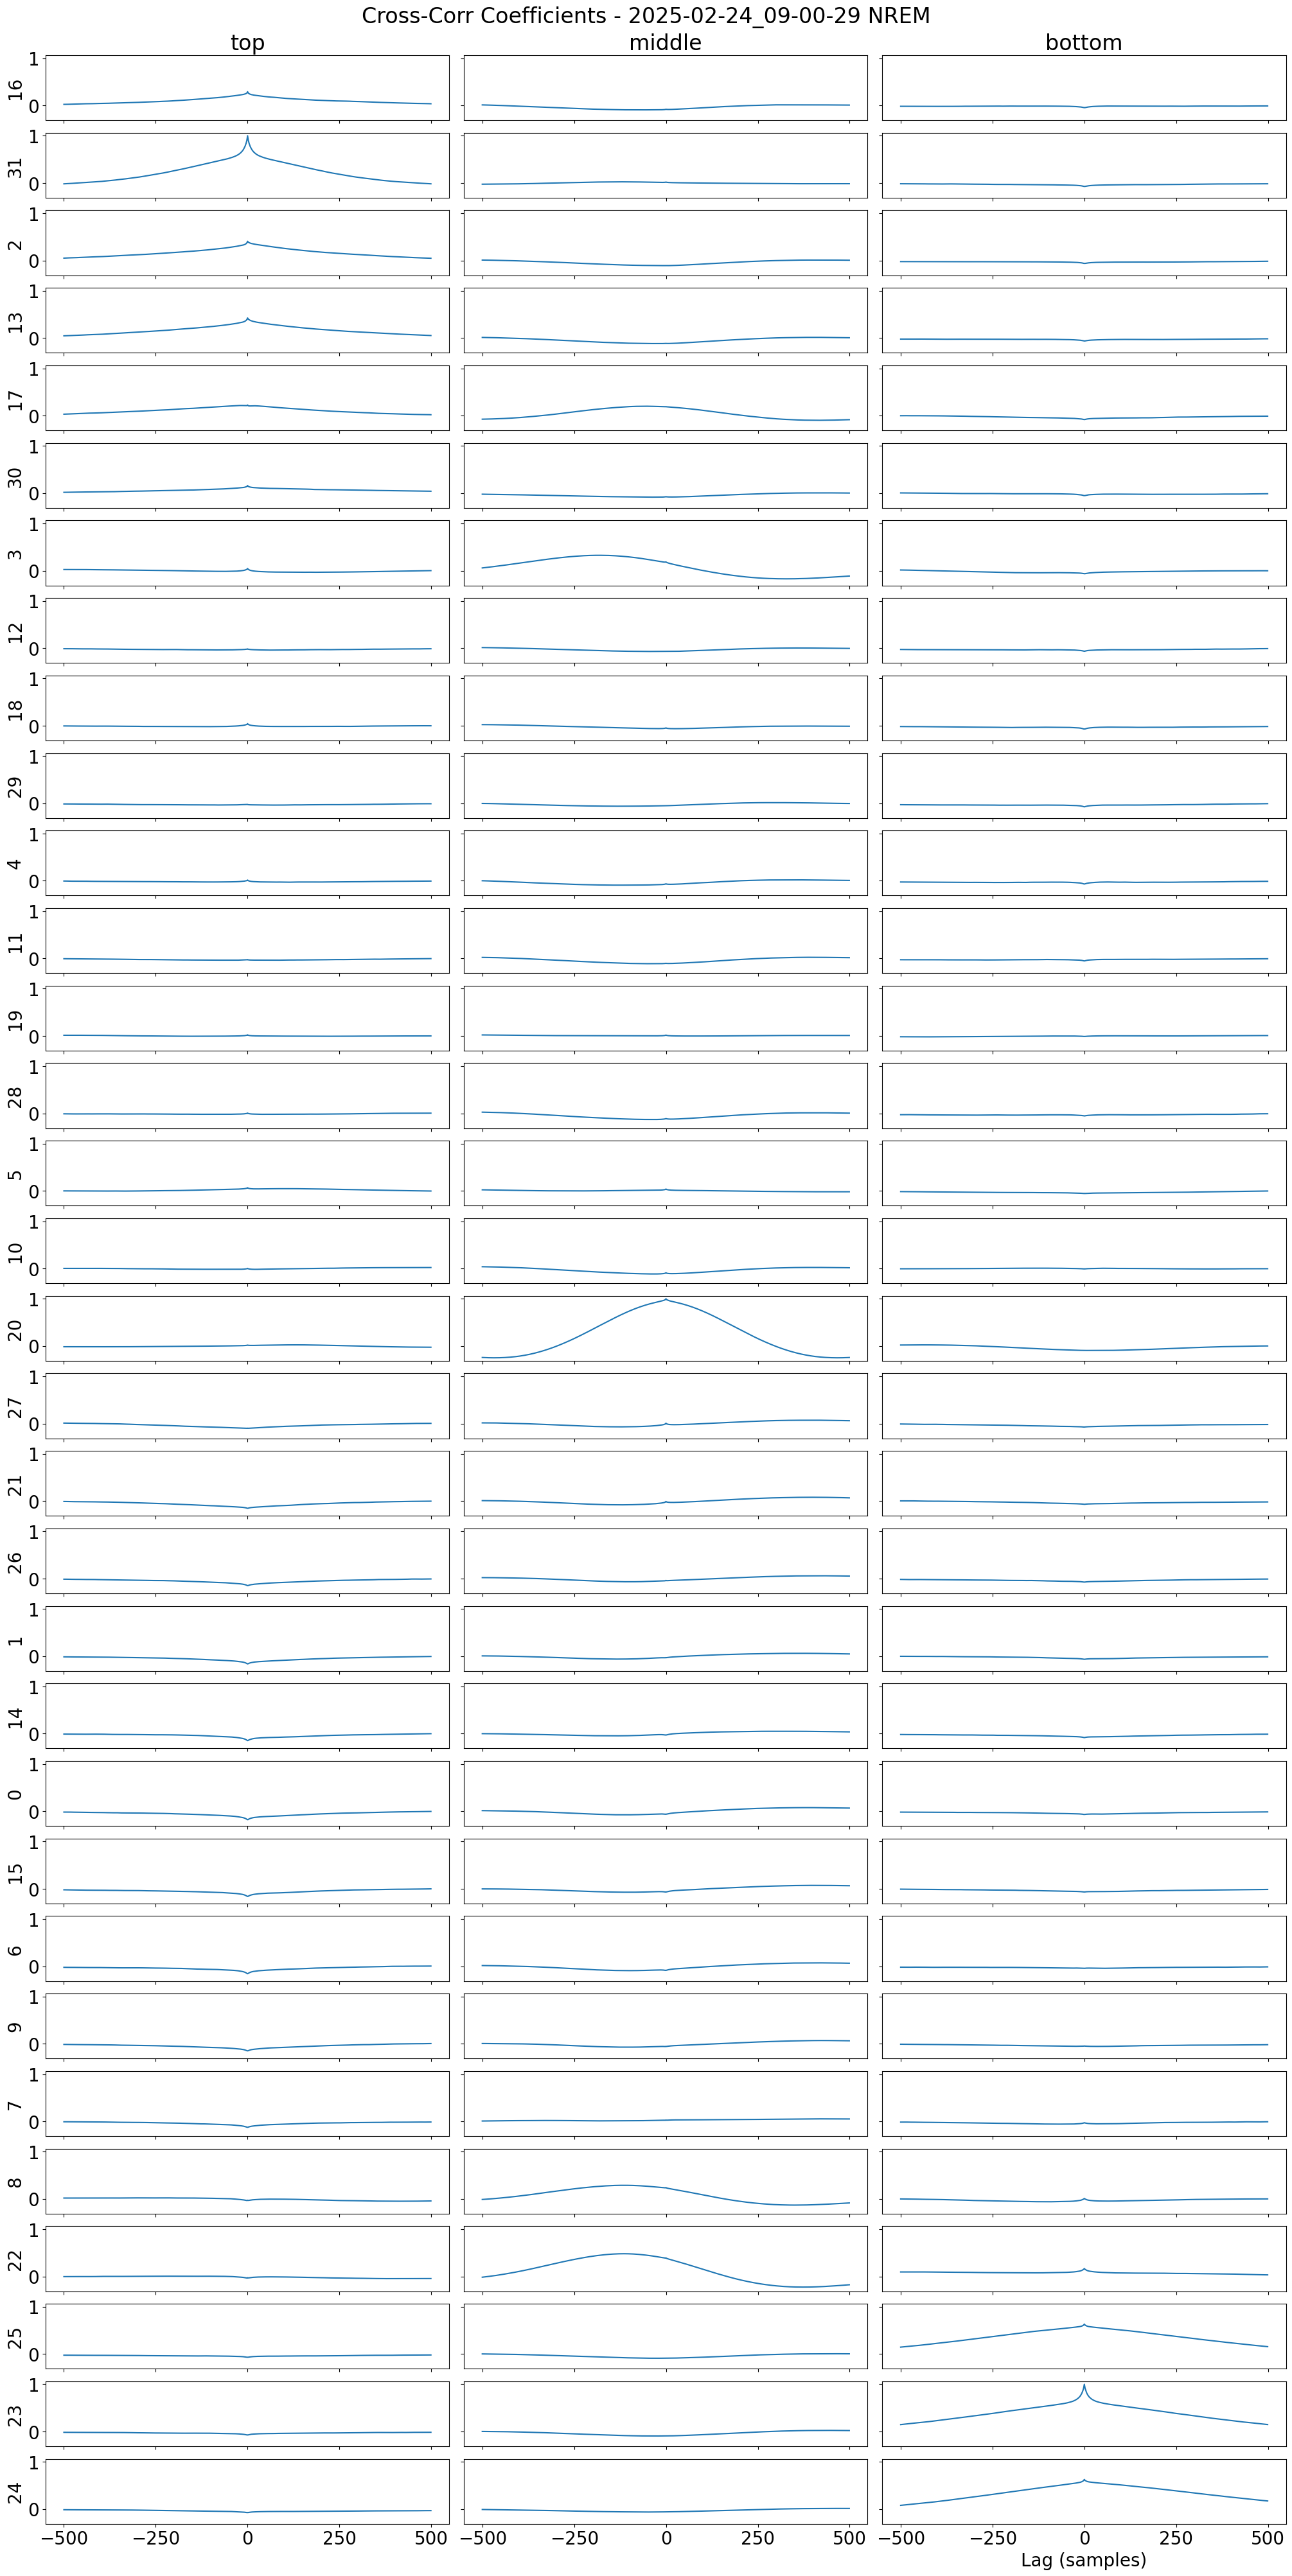

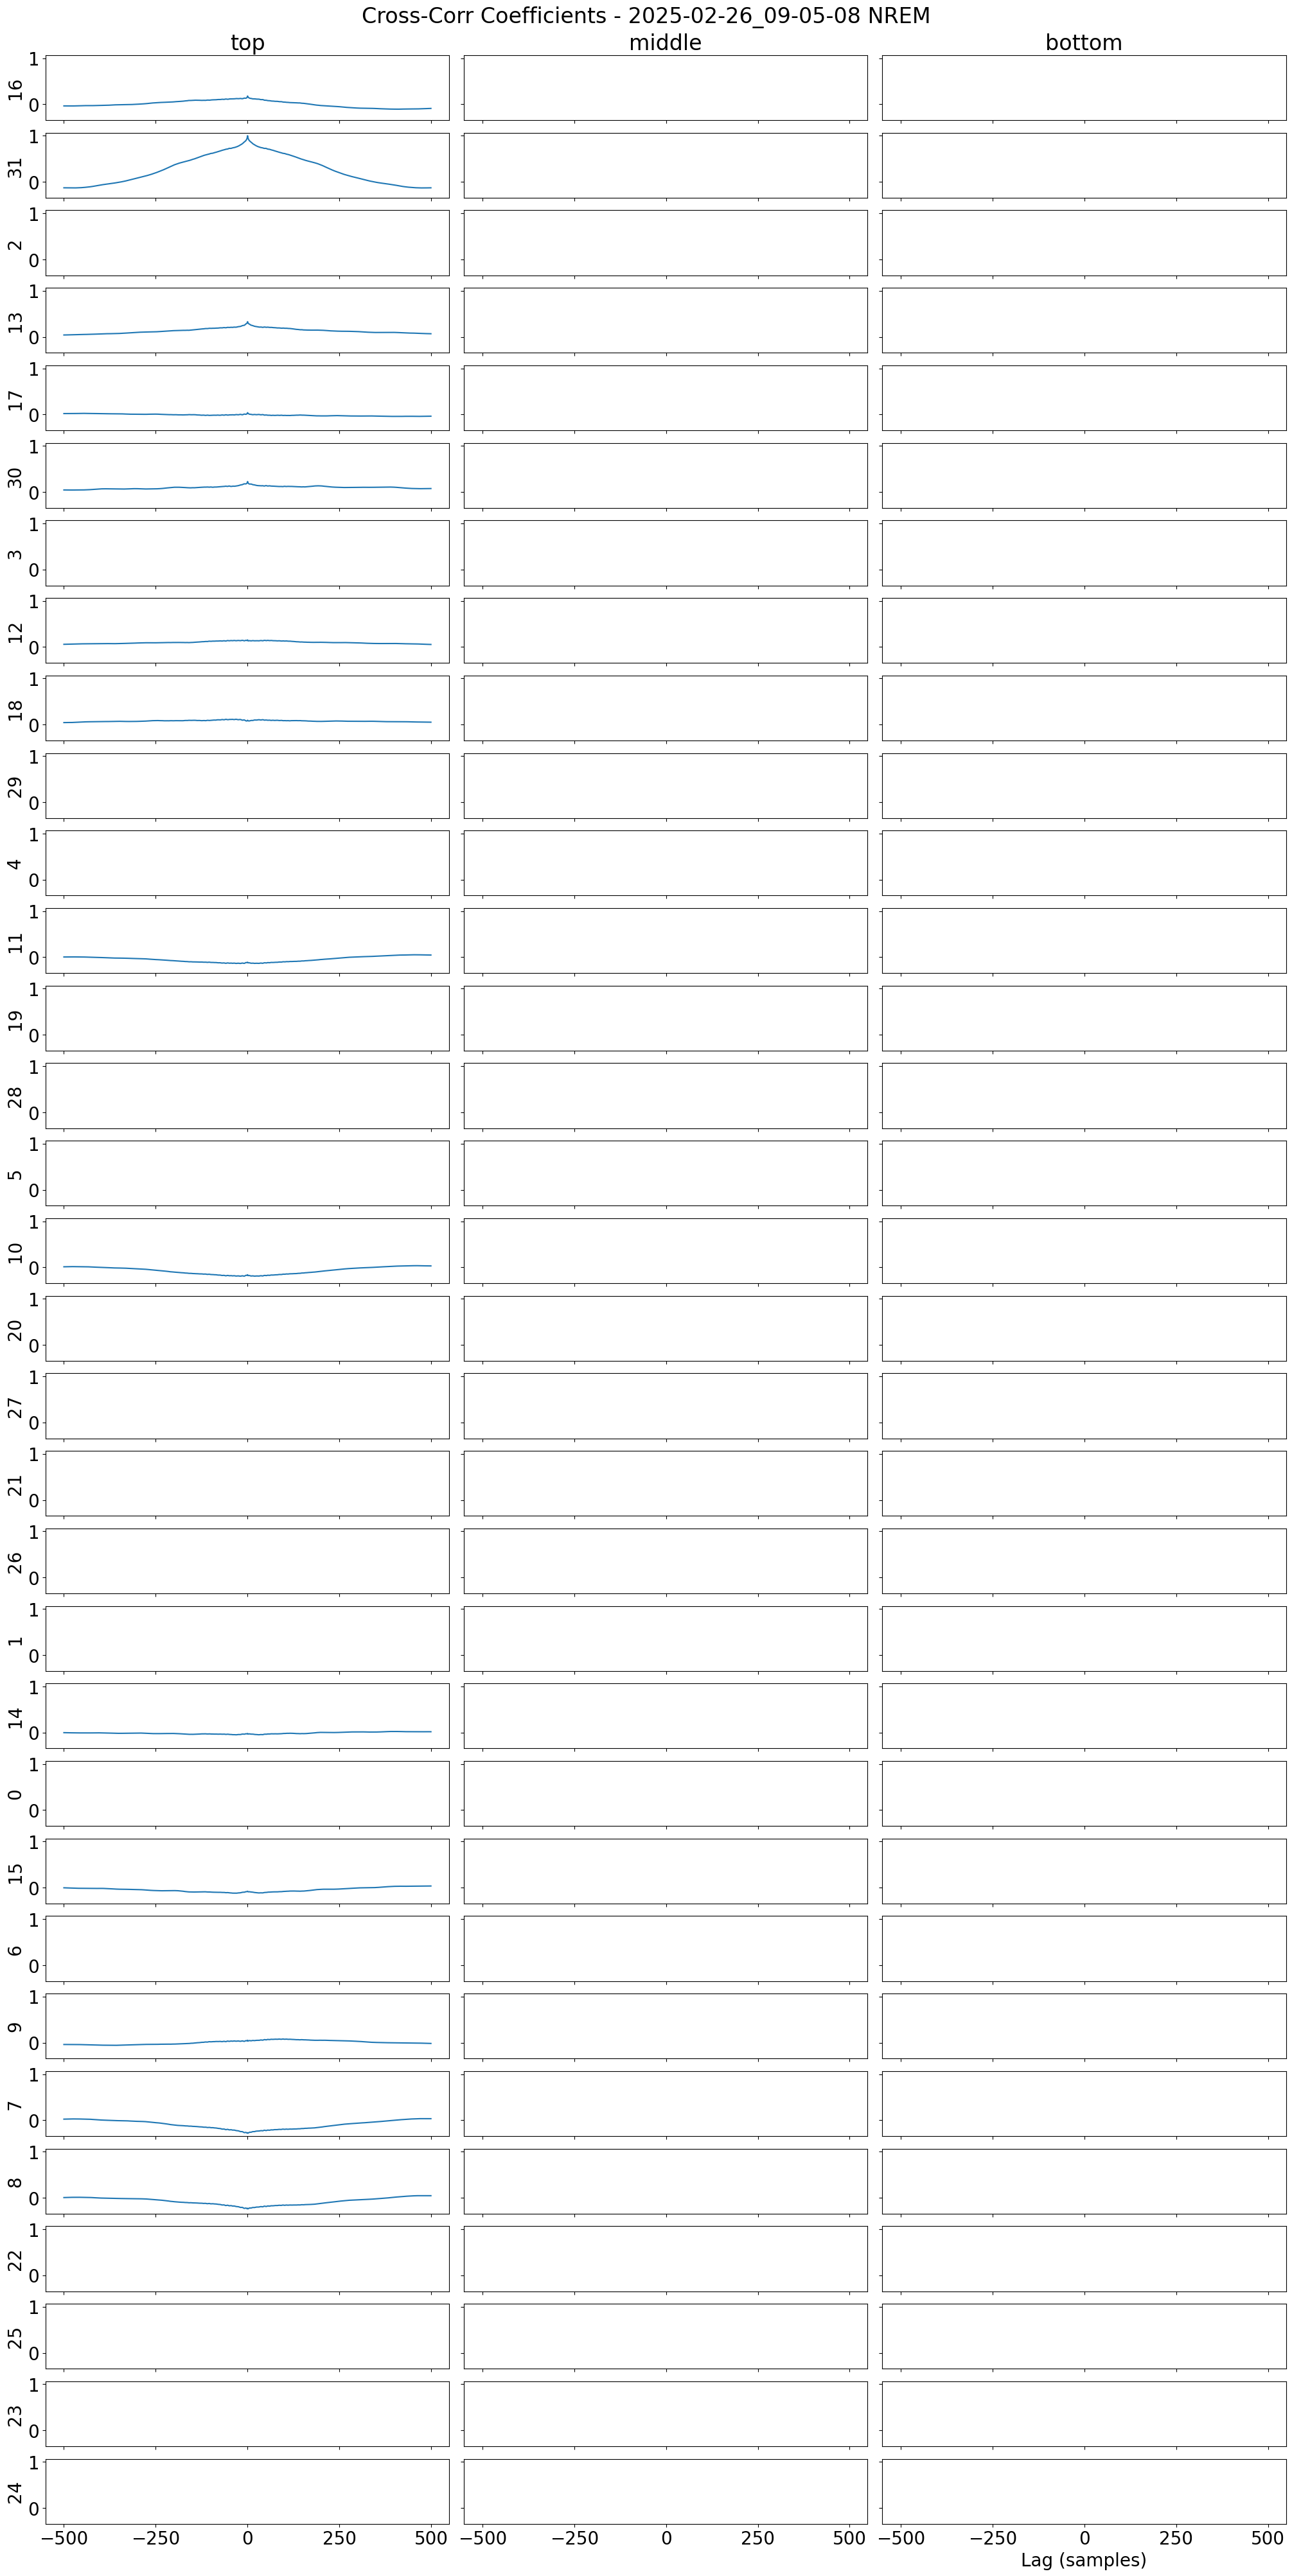

In [68]:
for date, xcf in date_xcf.items():
    fig, axs = plt.subplots(
        32, 3, figsize=(20, 40), sharex=True, sharey=True, constrained_layout=True
    )
    ticks = np.arange(1000) - 500
    for (i, ref), ref_zone in zip(enumerate(xcf), ["top", "middle", "bottom"]):
        sub_ax = axs[:, i]
        sub_ax[0].set_title(ref_zone)
        for j, ch_corr in enumerate(ref):
            sub_ax[j].plot(ticks, ch_corr)
            if i == 0:
                sub_ax[j].set_ylabel(depth_ordered_chs[::-1][j])
    _ = axs[-1, -1].set_xticks(ticks=[-500, -250, 0, 250, 500])
    _ = axs[-1, -1].set_xlabel("Lag (samples)")
    fig.suptitle(f"Cross-Corr Coefficients - {date} NREM")

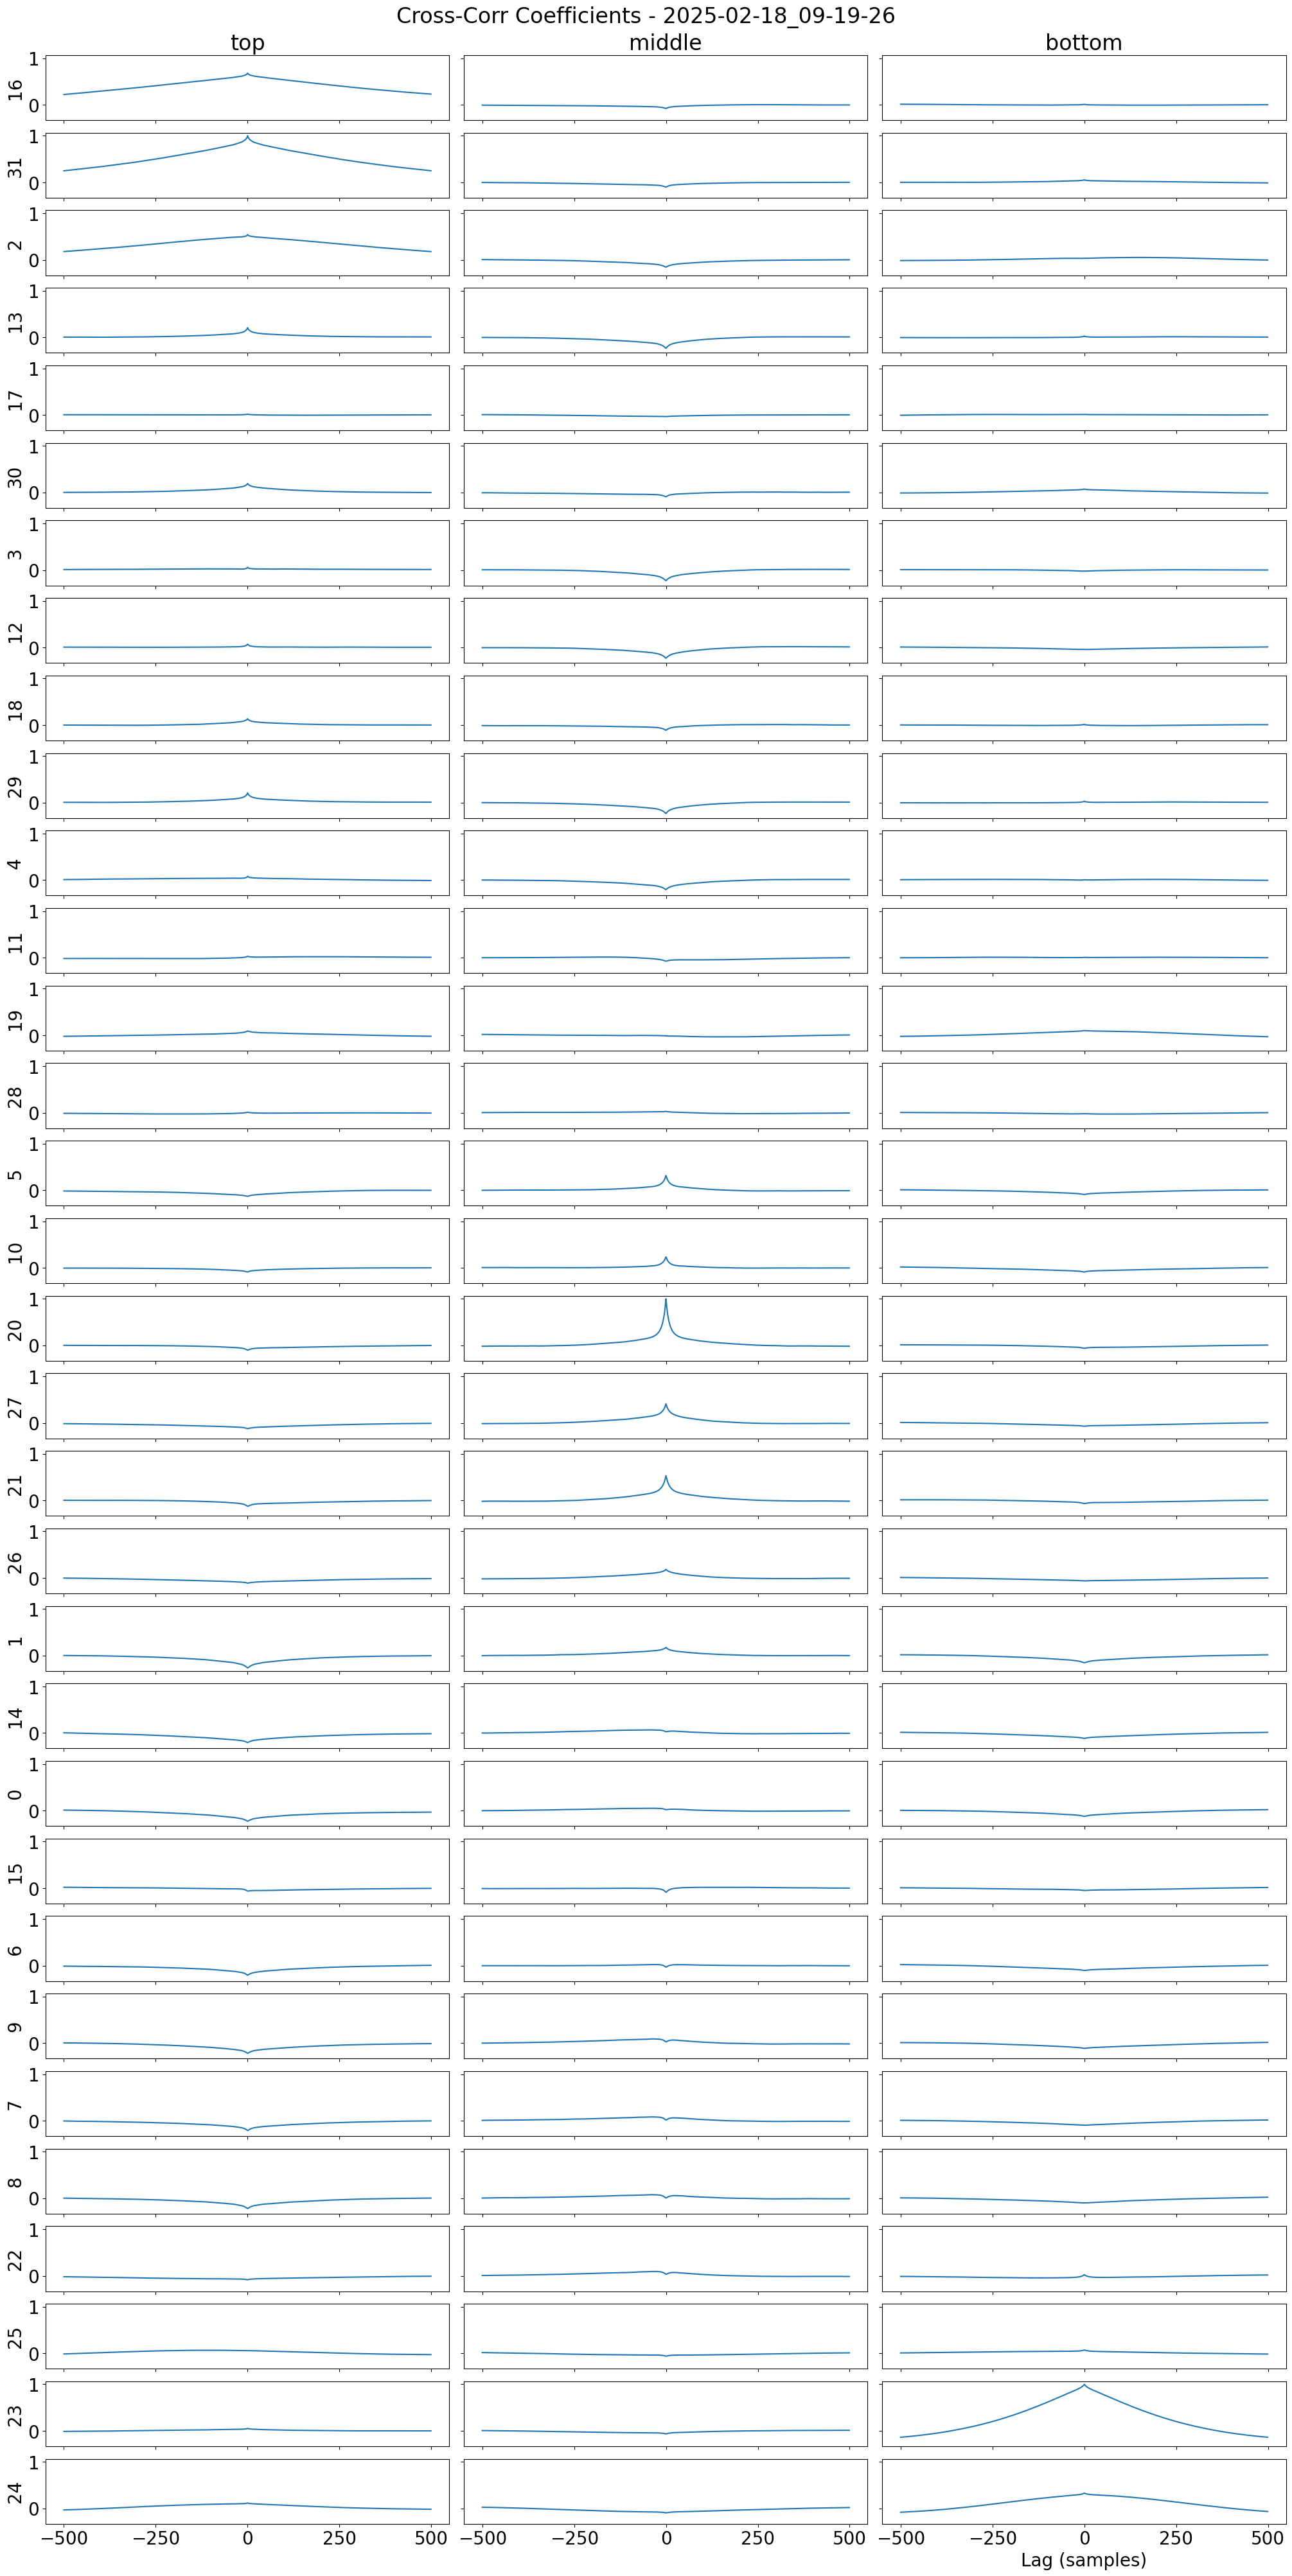

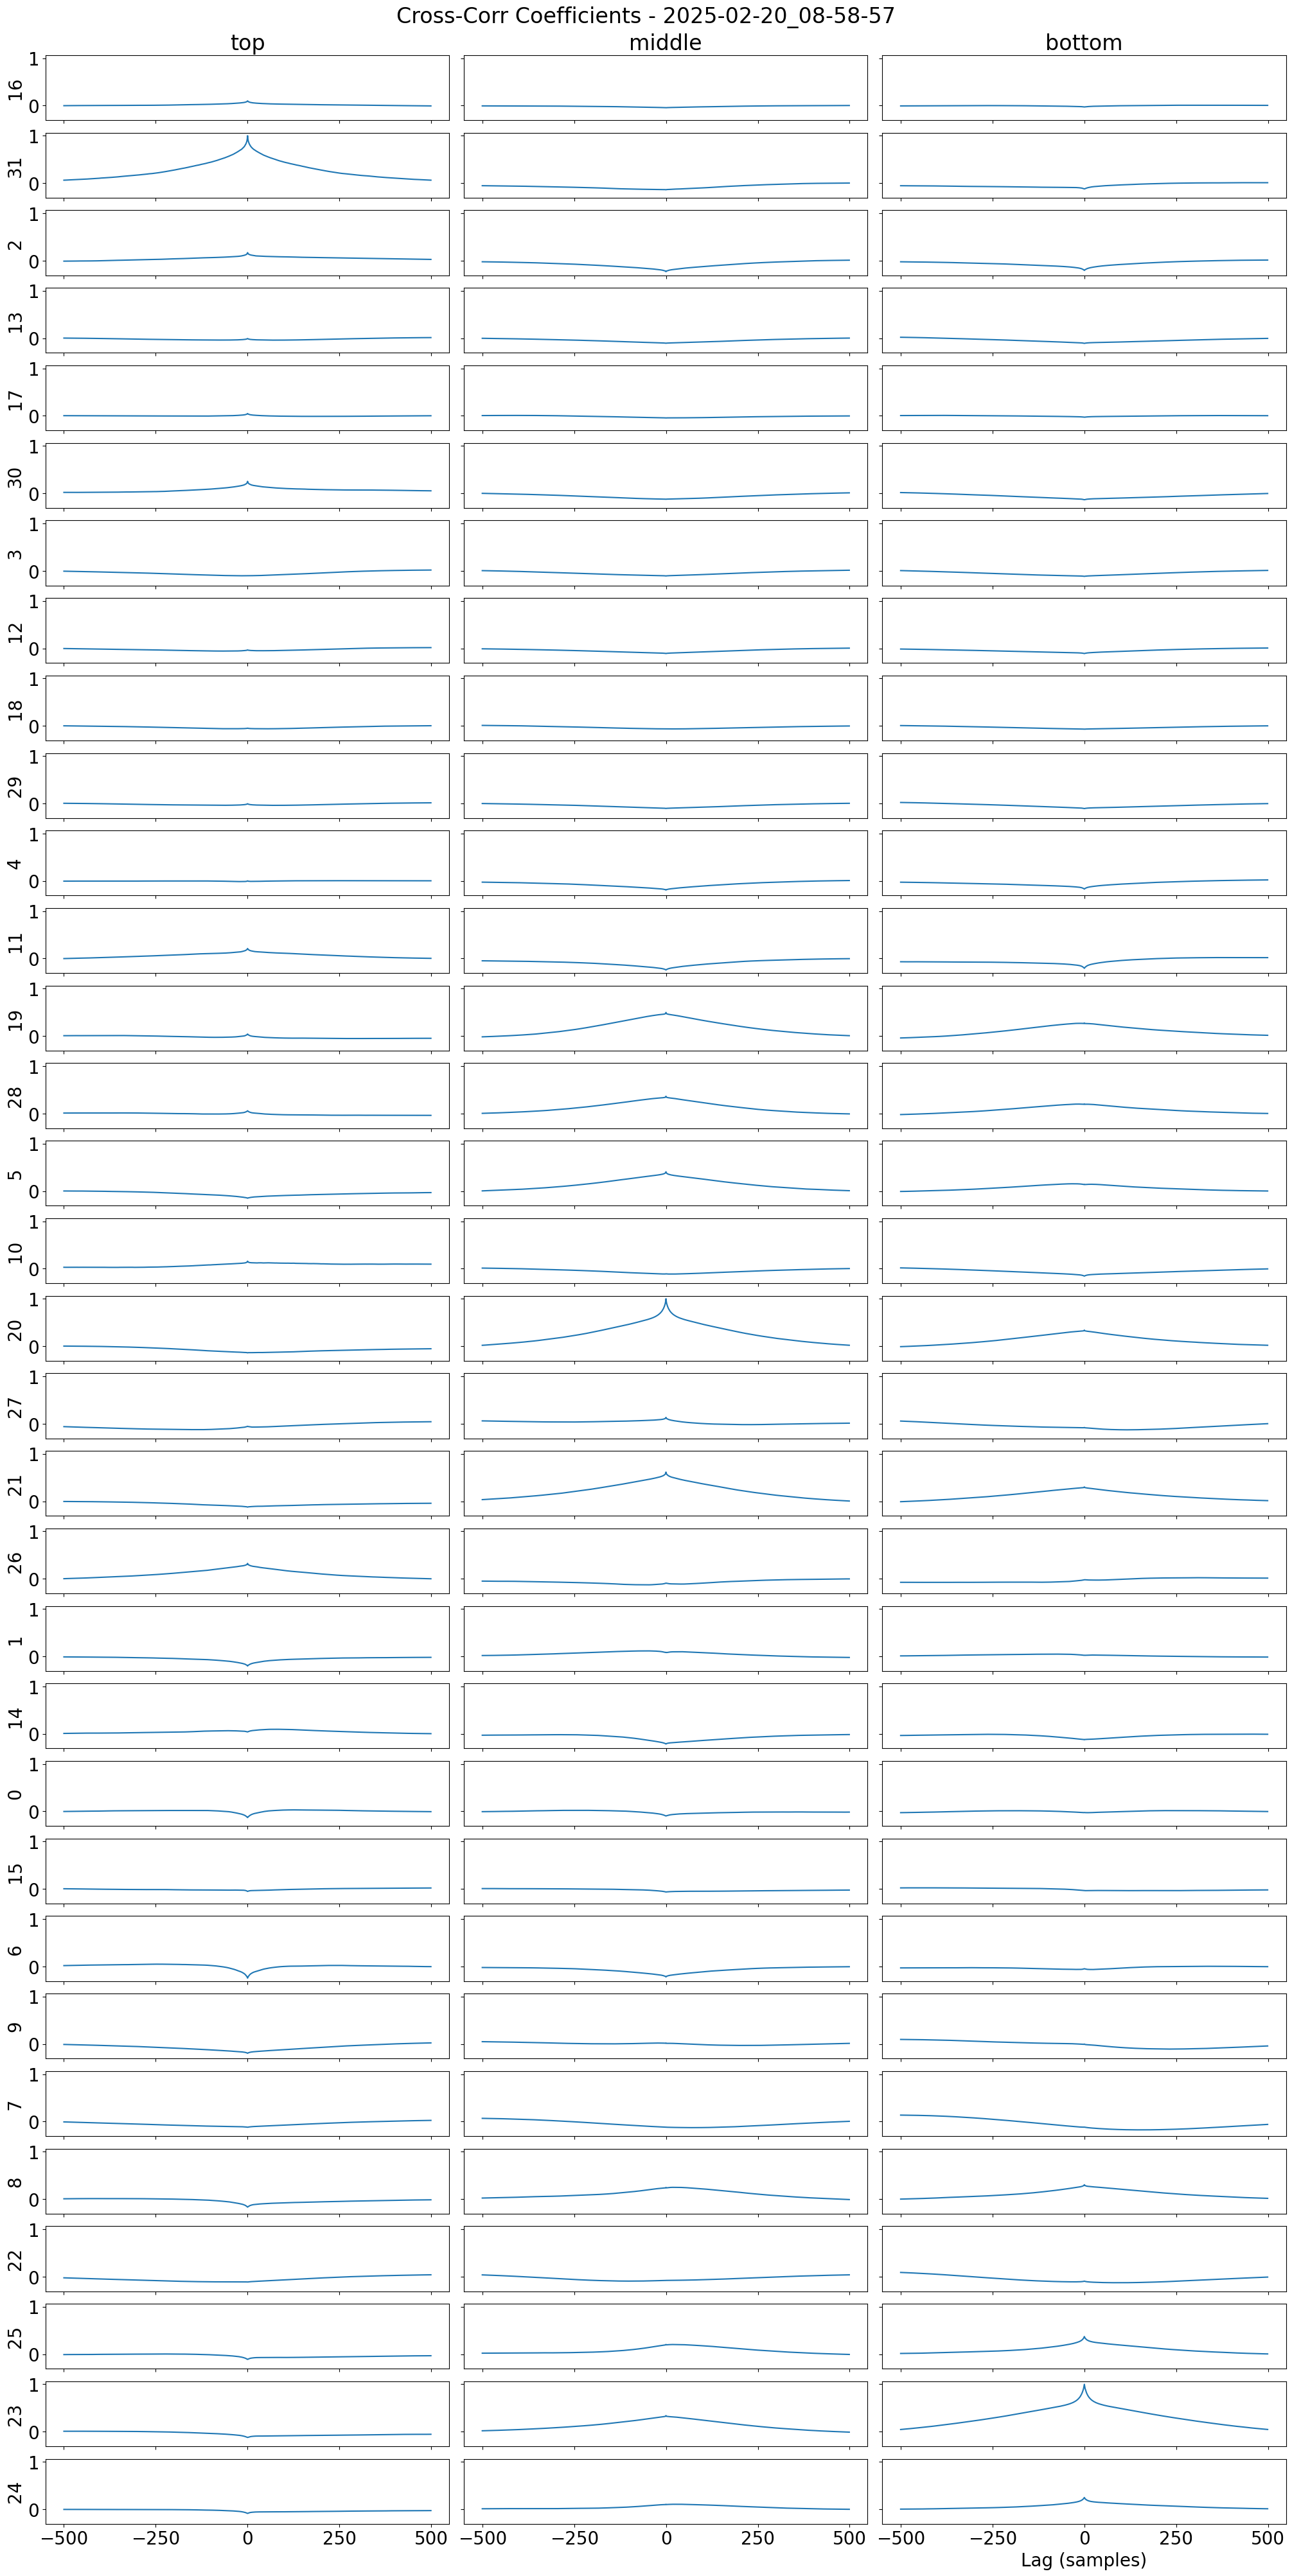

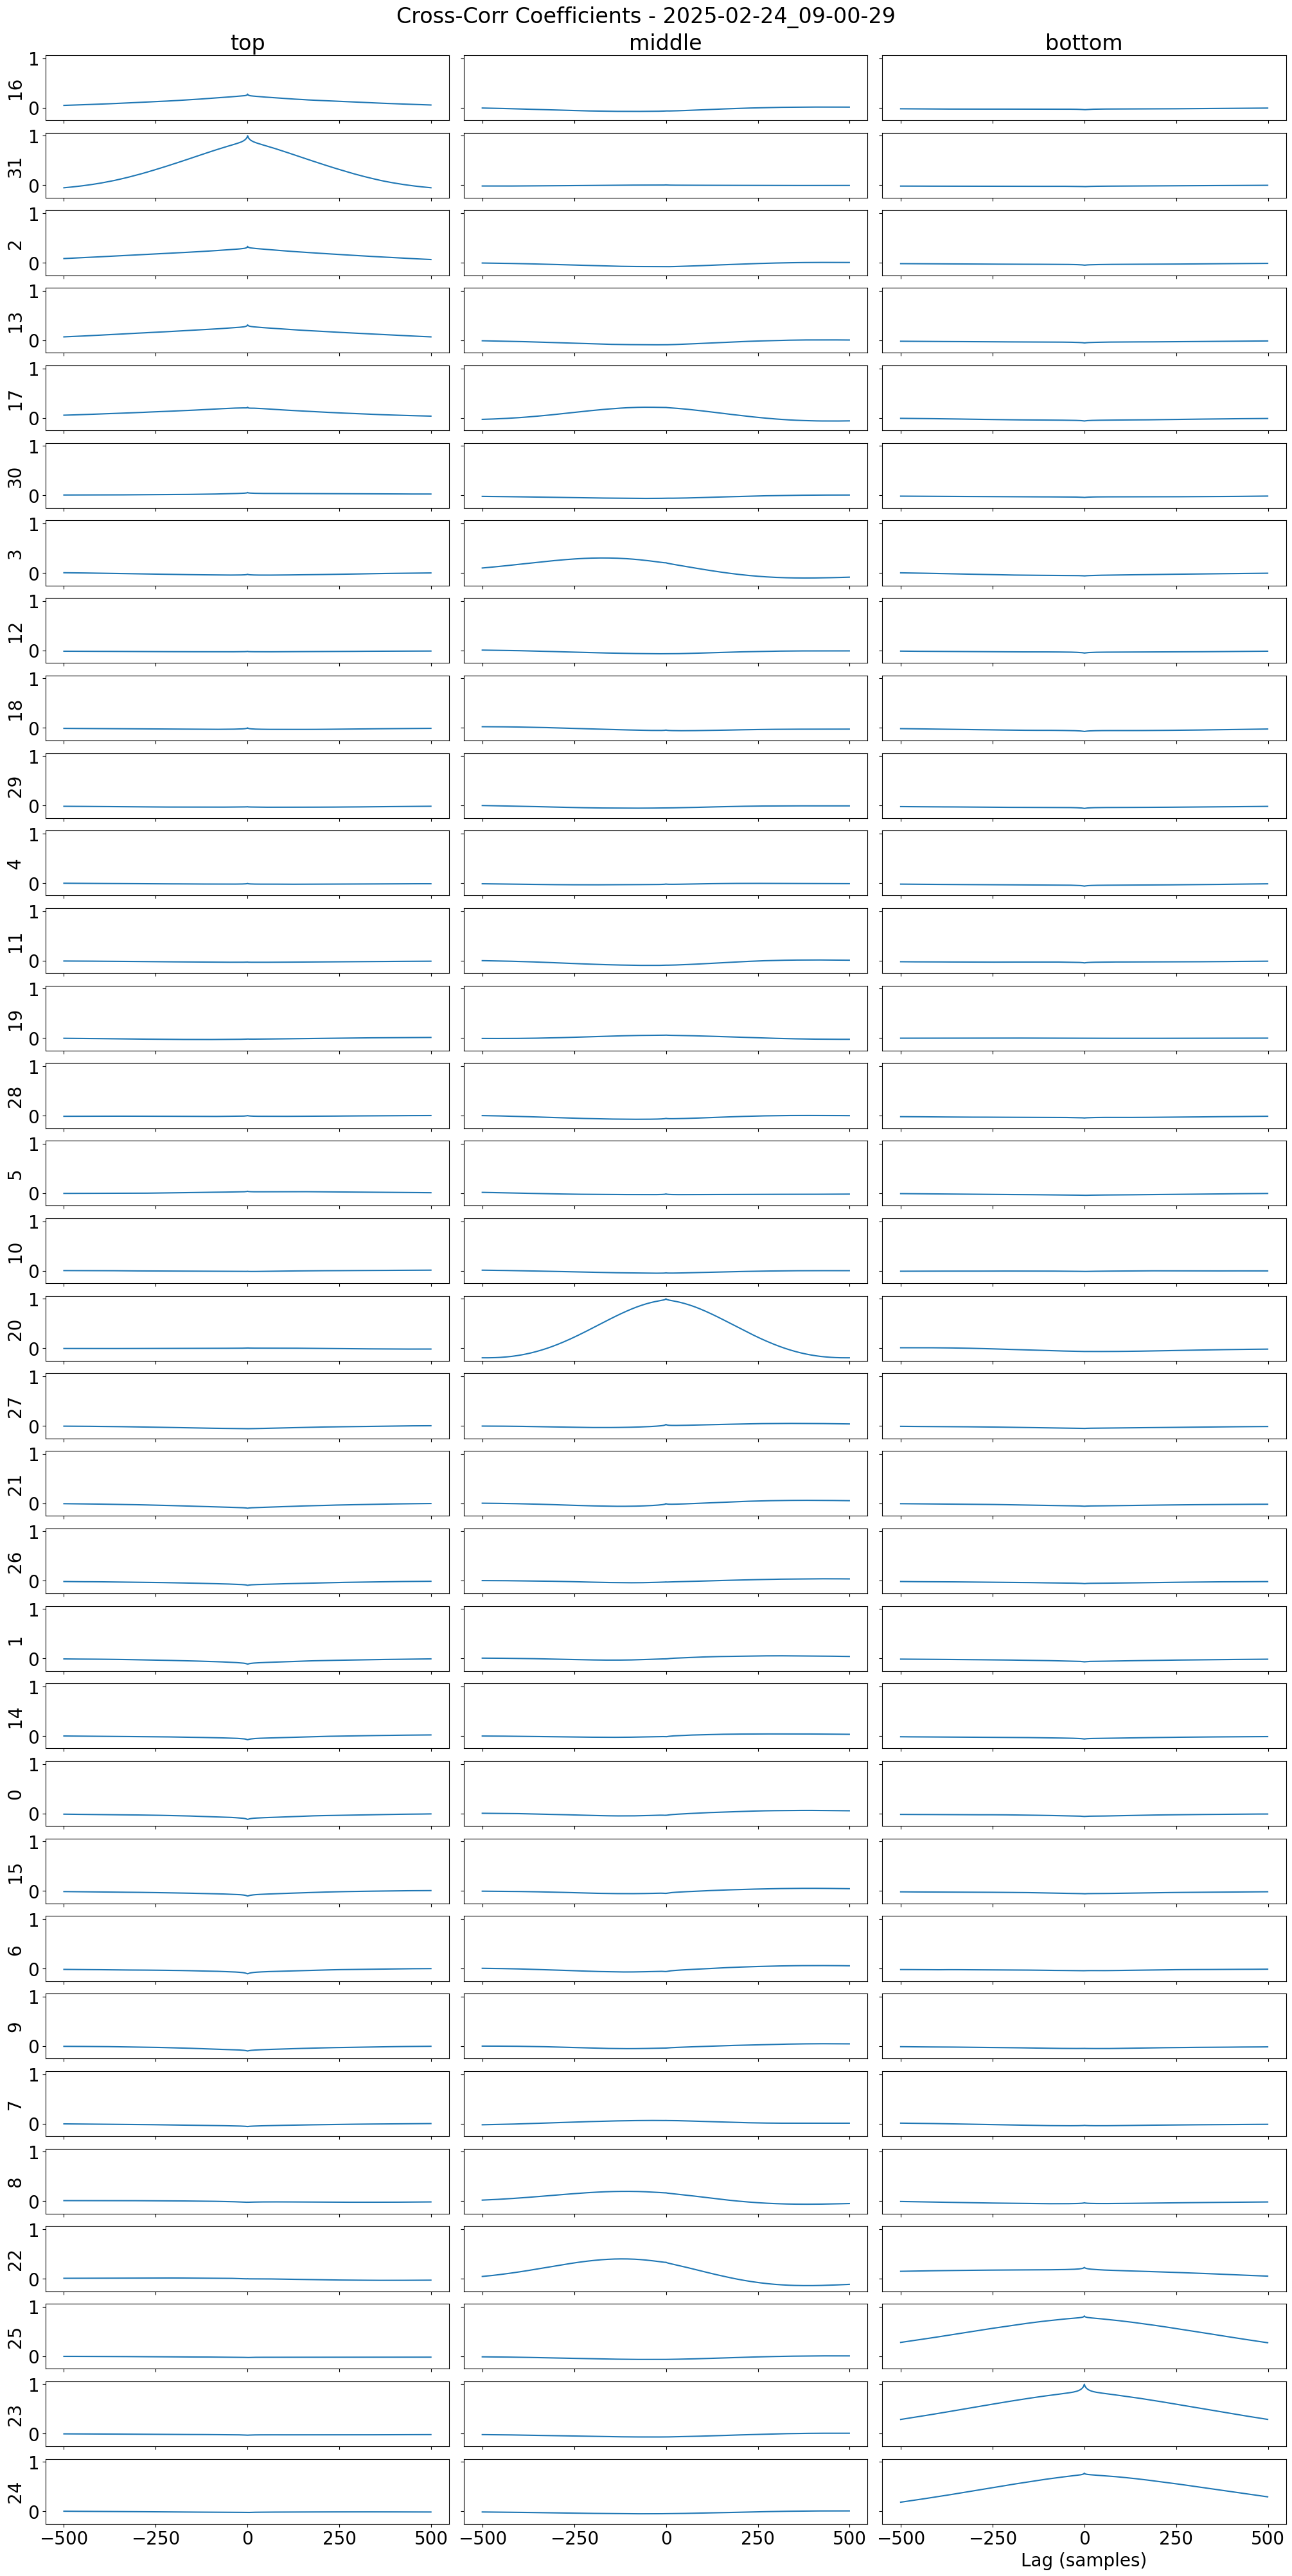

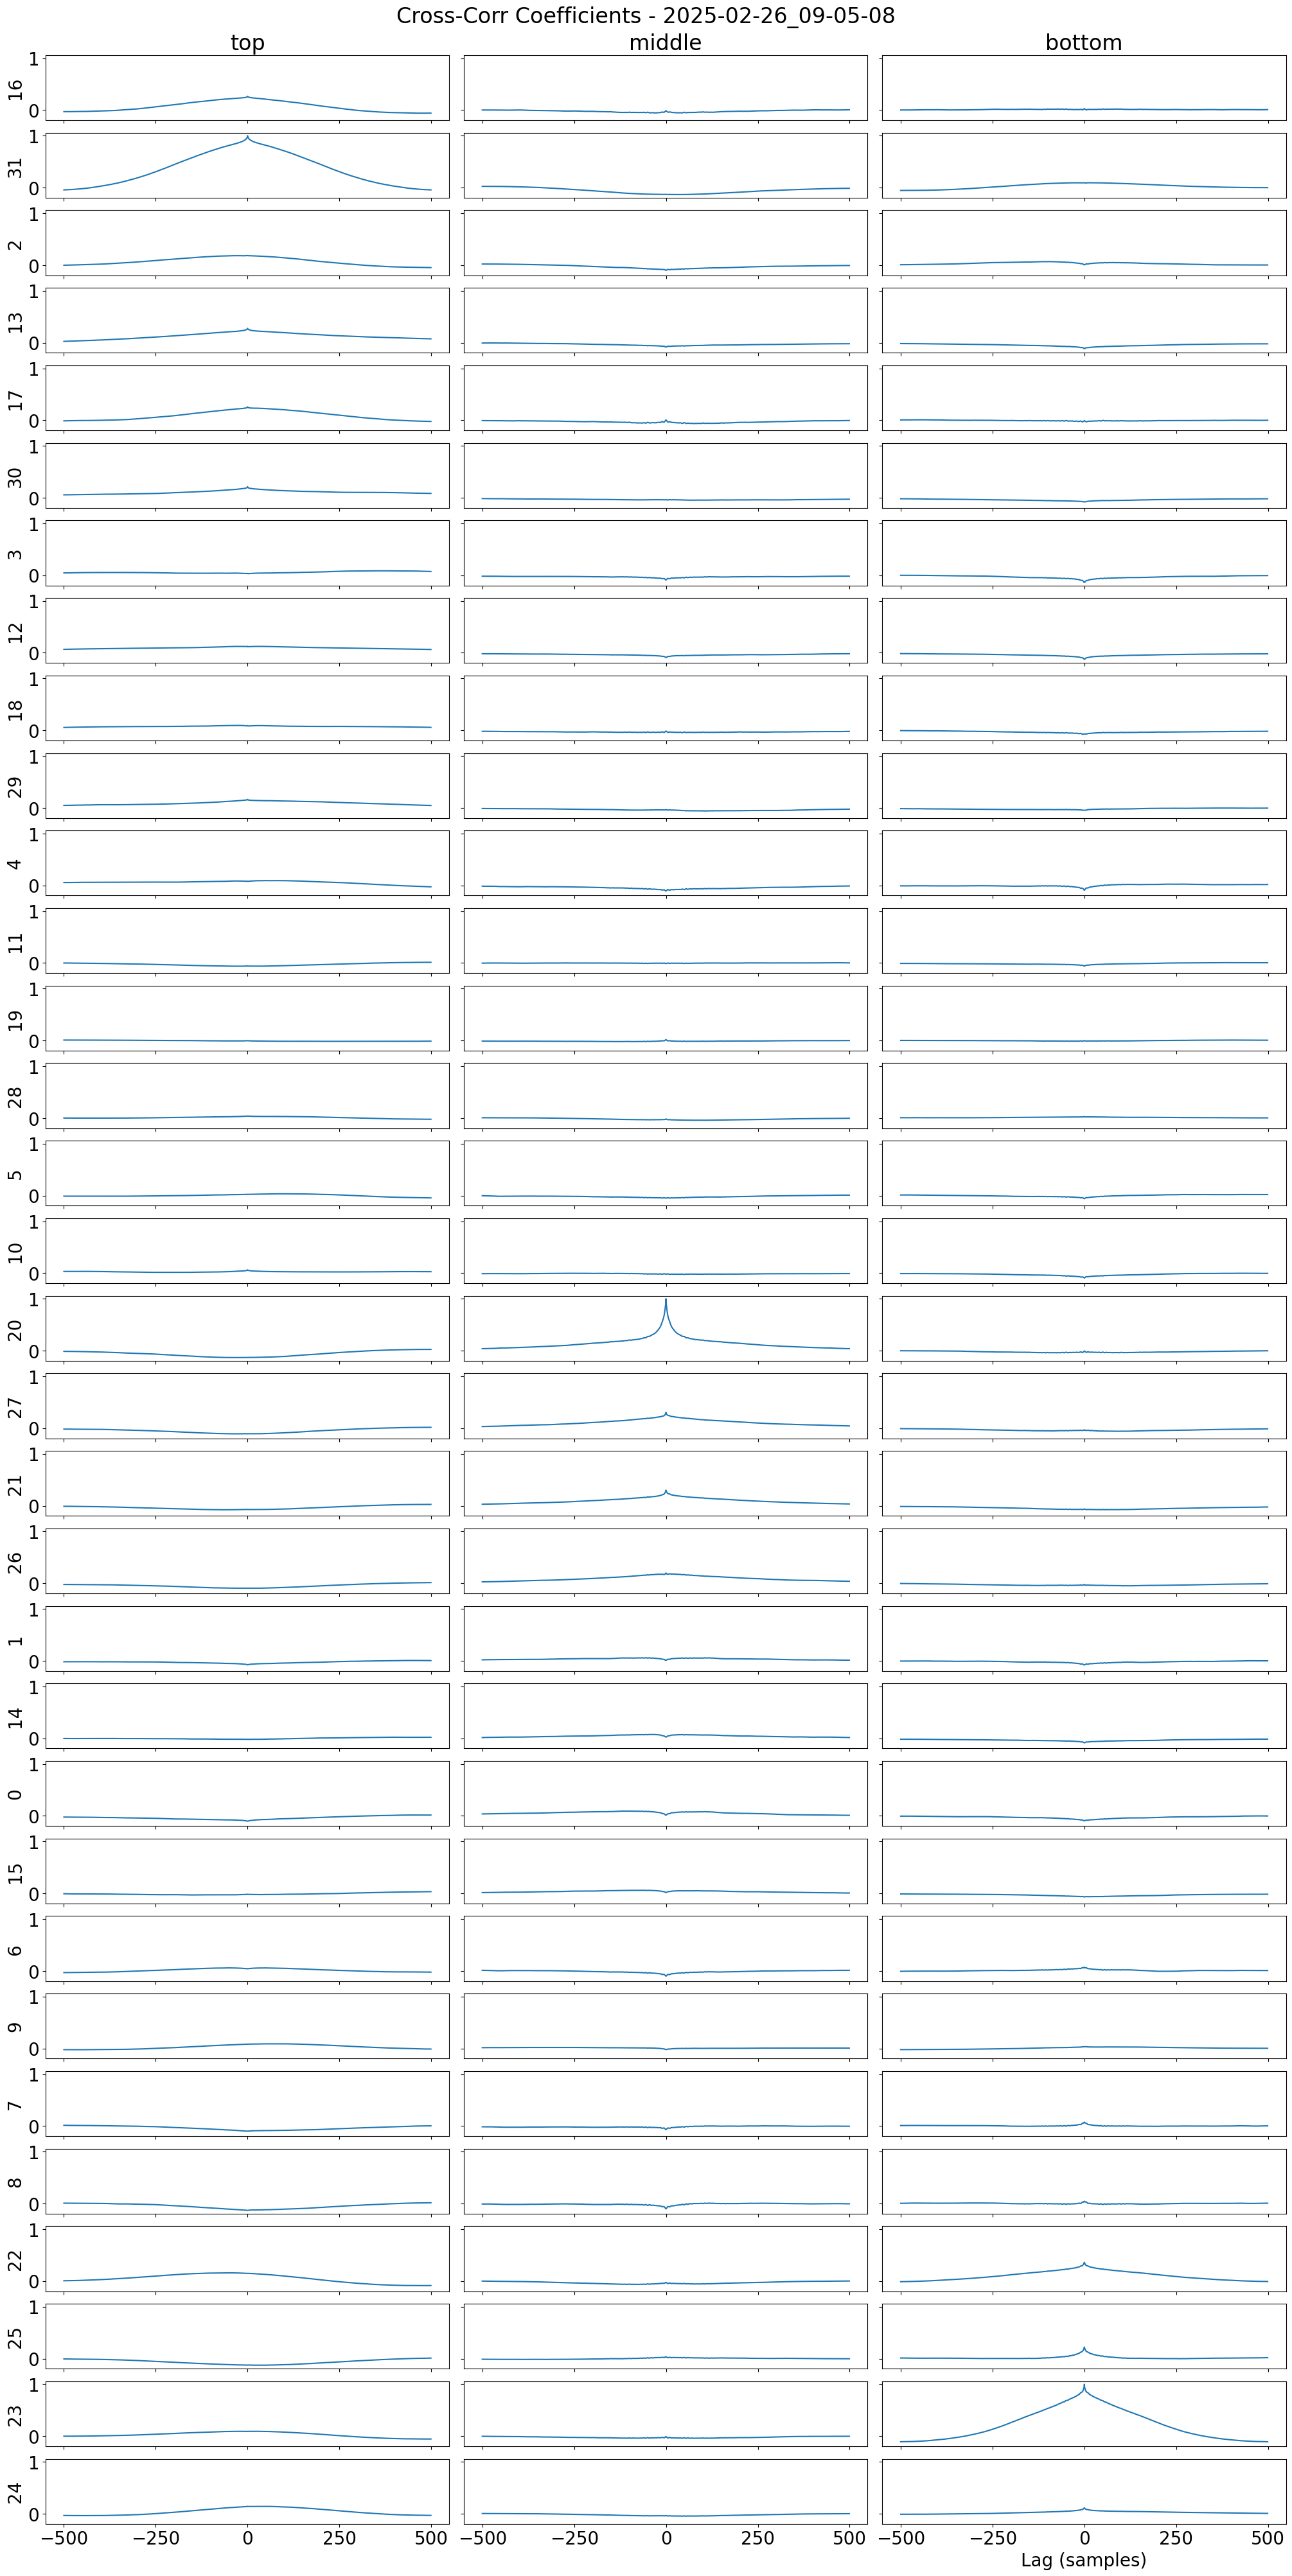

In [28]:
for date, xcf in date_xcf.items():
    fig, axs = plt.subplots(
        32, 3, figsize=(20, 40), sharex=True, sharey=True, constrained_layout=True
    )
    ticks = np.arange(1000) - 500
    for (i, ref), ref_zone in zip(enumerate(xcf), ["top", "middle", "bottom"]):
        sub_ax = axs[:, i]
        sub_ax[0].set_title(ref_zone)
        for j, ch_corr in enumerate(ref):
            sub_ax[j].plot(ticks, ch_corr)
            if i == 0:
                sub_ax[j].set_ylabel(depth_ordered_chs[::-1][j])
    _ = axs[-1, -1].set_xticks(ticks=[-500, -250, 0, 250, 500])
    _ = axs[-1, -1].set_xlabel("Lag (samples)")
    fig.suptitle(f"Cross-Corr Coefficients - {date}")